# [심화] 카이제곱 검정과 비모수 검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🎲 가정이 깨졌을 때, 무엇으로 검정할까

## — 카이제곱 검정과 비모수 검정

---

이전 시간에는 **평균**을 비교했습니다. 그런데 데이터가 숫자가 아니라 *범주*(생존 여부, 클릭 여부)거나, 정규성·등분산 같은 *가정*이 깨지면 t-test와 ANOVA를 그대로 쓸 수 없습니다. 오늘은 그럴 때 꺼내는 도구들을 배웁니다.

## 📋 학습 목표

이 노트북을 끝내면 여러분은 다음을 할 수 있습니다.

1. 범주형 데이터의 연관성을 **카이제곱 검정(Chi-Square Test)**으로 분석하고 결과를 해석할 수 있습니다.
2. **조건부확률과 베이즈 정리(Bayes' Theorem)**로 "사건이 일어난 뒤"의 확률을 다시 계산할 수 있습니다.
3. 정규성 가정이 깨진 데이터에 **비모수 검정**(Mann-Whitney·Wilcoxon·Kruskal-Wallis)을 적용할 수 있습니다.
4. 데이터 특성(연속/범주, 가정 충족/위배)에 따라 **적절한 검정을 스스로 선택**할 수 있습니다.
5. A/B 테스트 결과를 카이제곱으로 분석해 **의사결정 보고서**로 정리할 수 있습니다.

## 📚 학습 목차

| Part | 주제 | 이 파트에서 답할 질문 | ⏱ 예상 |
|------|------|----------------------| --- |
| 1 | 왜 다른 검정이 필요한가 | 평균을 못 쓰는 데이터는 어떻게 비교하나? | 5분 |
| 2 | 환경 준비와 오늘의 데이터 | 무엇을, 어떤 도구로 다루나? | 10분 |
| 3 | 검정 선택 지도 | 데이터를 보고 어떤 검정을 고르나? | 10분 |
| 4 | 카이제곱 검정 | 두 범주는 서로 관련이 있나? | 50분 |
| 5 | 조건부확률과 베이즈 정리 | "이미 일어난 일"의 확률은? | 35분 |
| 6 | 비모수 검정 3종 | 정규성이 깨지면 무엇으로 비교하나? | 50분 |
| 7 | 모수 vs 비모수, 그리고 A/B | 언제 무엇을 쓰고, A/B는 어떻게 분석하나? | 35분 |
| 🧪 | 종합 실습 | 실제 데이터로 검정을 선택·수행·보고할 수 있나? | 30분 |

*⏱ 예상 시간은 참고용 안내입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다.*

# Part 1. 왜 '다른 검정'이 필요한가

이전 시간 우리는 "두 집단의 **평균**이 다른가"를 t-test로, "여러 집단의 평균이 다른가"를 ANOVA로 따졌습니다. 두 도구에는 공통 전제가 있었습니다. **(1) 비교 대상이 숫자(연속형)이고, (2) 대체로 정규분포를 따른다**는 것입니다.

그런데 현실 데이터는 자주 이 전제를 벗어납니다.

- **숫자가 아니라 범주입니다.** "탑승객이 *생존했는가/사망했는가*", "광고를 *클릭했는가/안 했는가*" — 평균을 낼 수 없는 *예/아니오* 데이터입니다.
- **정규성이 깨졌습니다.** 결제 금액·응답 시간처럼 한쪽으로 길게 쏠린(우편향) 데이터는 평균이 대표값 노릇을 제대로 못 합니다.

이럴 때 평균 대신 **빈도(개수)**를 비교하거나, 값 대신 **순위(등수)**를 비교하는 검정이 필요합니다. 그게 오늘의 두 주인공 — **카이제곱 검정**과 **비모수 검정**입니다.

> ❓ **이 파트에서 답할 질문:** 평균을 쓸 수 없는 데이터(범주형·비정규)는 무엇으로 비교할까요?

> 🎯 **오늘의 핵심:** 검정은 외우는 공식이 아니라 **데이터 특성에 맞춰 고르는 도구**입니다. "이 데이터엔 어떤 검정이 맞을까?"를 묻는 습관이 오늘의 진짜 목표입니다.

오늘 다루는 도구는 크게 세 갈래입니다. 첫째, 범주형 데이터(예/아니오)의 연관을 보는 **카이제곱 검정**. 둘째, 확률을 거꾸로 뒤집어 "이미 일어난 일"의 원인을 추론하는 **조건부확률·베이즈 정리**. 셋째, 분포 가정이 깨졌을 때 값 대신 순위로 비교하는 **비모수 검정**. 셋 다 t-test·ANOVA가 손을 들 때 꺼내는 대안이라는 공통점이 있습니다. 처음 보는 이름이 많아도 부담 갖지 말고, 각 도구가 *어떤 상황을 위한 것인지*에만 집중하며 천천히 따라오세요. 하나씩 짚으면 어렵지 않습니다.

# Part 2. 환경 준비와 오늘의 데이터

먼저 라이브러리를 불러오고, 오늘 사용할 실제 데이터를 준비합니다. 아래 셀을 위에서부터 차례로 실행하세요.

> ⚠️ **주의:** 코드 셀은 반드시 위에서부터 순서대로 실행하세요. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 납니다.

## 1단계 · 환경 준비 — 라이브러리·한글 폰트·시드 고정

In [1]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm   # 내장 데이터(china_smoking)·보조 도구

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. (시뮬레이션 셀에 적용)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", scipy.__version__)

준비 완료!
numpy : 2.0.2
pandas: 2.2.2
scipy : 1.16.3


## 📖 핵심 용어 사전

오늘 처음 나오는 기호만 추렸습니다. 막히면 여기로 돌아오세요.

| 기호 | 읽는 법 | 의미 |
|------|---------|------|
| $O$ | 관측빈도 (Observed) | 실제로 센 개수 |
| $E$ | 기대빈도 (Expected) | "관련이 없다면" 기대되는 개수 |
| $\chi^2$ | 카이제곱 | 관측과 기대의 어긋남을 모은 통계량 |
| $df$ | 자유도 | (행 수 − 1) × (열 수 − 1) — $\chi^2$ 분포의 모양을 결정 |
| Cramér's V | 크라메르 브이 | 카이제곱의 **효과 크기**(0~1, 연관의 세기) |
| $OR$ | 오즈비 (Odds Ratio) | 두 집단의 **오즈**(성공/실패 비)의 비율. 1이면 차이 없음 |
| $P(A)$ | 사건 A의 확률 | A가 일어날 확률 |
| $P(A \mid B)$ | 조건부확률 | *B가 일어났을 때* A의 확률 |
| 순위(Rank) | — | 값을 크기순으로 매긴 등수 |

> 💡 비모수 검정은 "값" 대신 이 **순위**를 씁니다. 그래서 극단값(이상치)에 둔감합니다.

### 📖 오즈와 오즈비 — 비율과 어떻게 다른가

뒤에서 자주 쓰게 되니 지금 한 번 정리합니다. **오즈(Odds)** 는 "일어날 확률 ÷ 안 일어날 확률"입니다.

| 개념 | 계산 | 예 (연락률 10%) |
| --- | --- | --- |
| **비율(확률)** | 성공 ÷ 전체 | $10/100 = 0.10$ |
| **오즈** | 성공 ÷ 실패 | $10/90 = 0.111$ |
| **오즈비(OR)** | 한 집단의 오즈 ÷ 다른 집단의 오즈 | A가 0.111, B가 0.176이면 $OR = 1.58$ |

- $OR = 1$ → 두 집단의 오즈가 같다(연관 없음)
- $OR > 1$ → 첫 집단에서 그 사건이 더 잘 일어난다
- $OR < 1$ → 덜 일어난다

> ⚠️ **오즈비는 "몇 배 더 잘 일어난다"가 아닙니다.** 확률의 비(위험비)와 다른 값입니다. 사건이 드물 때는(비율 < 10% 정도) 둘이 비슷해지지만, 흔한 사건에서는 오즈비가 훨씬 커 보입니다. 그래서 보고할 때는 **오즈비와 함께 각 집단의 실제 비율**을 나란히 적는 것이 정직합니다.

## 오늘 쓸 실제 데이터

여섯 가지 실제 데이터를 씁니다. **모두 라이브러리가 함수 하나로 제공**하므로 따로 파일을 준비할 필요가 없습니다.

| 데이터 | 어디서 오나 | 오늘의 쓰임 |
| --- | --- | --- |
| `titanic` | seaborn | 생존 여부 × 성별·객실등급 → **카이제곱 독립성**, 조건부확률 |
| `tips` | seaborn | 결제액(우편향) → **Mann-Whitney U** |
| `penguins` | seaborn | 종별 체중 → **Kruskal-Wallis** |
| `china_smoking` | statsmodels **내장** | 흡연 × 폐암 분할표 → 고전 카이제곱 + 오즈비 |
| `jtrain` | statsmodels → Rdatasets(`wooldridge`) | 같은 기업의 87/88 불량률 → **Wilcoxon 부호순위** |
| `ResumeNames` | statsmodels → Rdatasets(`AER`) | 무작위 배정 현장실험 → **A/B 테스트형 카이제곱** |

앞의 세 데이터는 [D012] 기술통계·분포, [D013] t-test·ANOVA에서도 썼던 그 데이터이고, `jtrain`은 D013에서 대응표본 t-test에 썼던 데이터입니다(오늘은 그 비모수 짝꿍을 적용합니다).

> 📎 **`ResumeNames`가 무엇인가** — 동일한 내용의 이력서에 **이름만 무작위로 바꿔** 4,870건을 실제 구인공고에 보내고, 면접 연락(callback)이 오는지 기록한 현장실험 자료입니다(Bertrand & Mullainathan, 2004, *American Economic Review*). 구조가 A/B 테스트와 똑같습니다 — **두 그룹 × 예/아니오 결과**. 오늘은 이 데이터로 "그룹에 따라 성공률이 다른가"를 카이제곱으로 판정하는 연습을 합니다.
>
> ⚠️ **다루는 태도:** 이 자료는 채용 과정의 차별을 측정한 사회과학 연구입니다. 우리는 이것을 *통계 도구를 배우는 실제 사례*로 다루되, 결과를 가볍게 일반화하지 않고 "이 표본에서 관측된 연락률 차이"로 정확히 표현합니다.

## 2단계 · 실습 데이터 6종 불러오기

In [2]:
# [C2] ── 실습 데이터 로드 — 모두 라이브러리가 제공하는 데이터셋 ──
#   · titanic  (seaborn)                : 생존·성별·등급        → 카이제곱
#   · tips     (seaborn)                : 결제액(우편향)        → Mann-Whitney
#   · penguins (seaborn)                : 종·체중              → Kruskal-Wallis
#   · jtrain   (statsmodels/Rdatasets)  : 같은 기업 87/88 불량률 → Wilcoxon
#   · ResumeNames (statsmodels/Rdatasets): 무작위 현장실험      → A/B형 카이제곱

titanic = sns.load_dataset("titanic")
tips    = sns.load_dataset("tips")

# 체중·종·성별에 결측이 있는 행은 검정에서 쓸 수 없으므로 미리 제거합니다.
penguins = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species", "sex"])  # 결측(NaN) 제거

# 같은 기업(fcode)의 1987 vs 1988 불량률 — '짝지어진' 두 측정
jtrain = sm.datasets.get_rdataset("jtrain", "wooldridge").data
scrap = (jtrain.pivot_table(index="fcode", columns="year", values="scrap")  # 행=대상, 열=시점으로 재배열 (짝 만들기)
                [[1987, 1988]].dropna())                          # 결측(NaN) 제거
before, after = scrap[1987], scrap[1988]

# 이력서 현장실험 — 그룹(이름 유형) × 결과(면접 연락 여부)
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data

print("titanic :", titanic.shape, "| 컬럼 예:", list(titanic.columns[:6]))
print("tips    :", tips.shape, "| 컬럼 예:", list(tips.columns))
print("penguins:", penguins.shape, "| 종:", penguins["species"].unique().tolist())
print("scrap   :", scrap.shape, f"| 87·88년 모두 기록된 기업 {len(scrap)}곳")
print("resume  :", resume.shape, "| 그룹:", resume["ethnicity"].unique().tolist(),
      "| 결과:", resume["call"].unique().tolist())
print()
print("titanic 미리보기 (생존·성별·등급):")
print(titanic[["survived", "sex", "class", "embarked", "fare"]].head())

titanic : (891, 15) | 컬럼 예: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch']
tips    : (244, 7) | 컬럼 예: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
penguins: (333, 7) | 종: ['Adelie', 'Chinstrap', 'Gentoo']
scrap   : (54, 2) | 87·88년 모두 기록된 기업 54곳
resume  : (4870, 27) | 그룹: ['cauc', 'afam'] | 결과: ['no', 'yes']

titanic 미리보기 (생존·성별·등급):
   survived     sex  class embarked     fare
0         0    male  Third        S   7.2500
1         1  female  First        C  71.2833
2         1  female  Third        S   7.9250
3         1  female  First        S  53.1000
4         0    male  Third        S   8.0500


## 🚦 짚고 넘어가기 — Part 2 환경과 데이터

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. t-test/ANOVA를 쓰기 어려운 데이터의 두 가지 상황은 무엇인가요?
2. "관측빈도"와 "기대빈도"는 각각 무엇을 뜻하나요?
3. 비모수 검정이 값 대신 사용하는 것은 무엇인가요?

> 💡 **다음 Part 예고:** 도구가 여러 개면 *고르는 기준*이 먼저 필요합니다. Part 3에서 **검정 선택 지도**부터 펼쳐 큰 그림을 잡습니다.

# Part 3. 검정 선택 지도 — 데이터를 보고 도구를 고른다

검정이 여러 개라 헷갈리시죠? 사실 선택의 갈림길은 단 두 개의 질문입니다. **"비교 대상이 연속형인가, 범주형인가?"** 그리고 **"분포 가정이 충족되는가, 위배되는가?"**

> ❓ **이 파트에서 답할 질문:** 손에 든 데이터를 보고, 어떤 검정을 골라야 하는지 어떻게 판단할까요?

## 💡 쉽게 말하면 — 증상에 따라 진료과가 갈리듯

병원에 가면 증상에 따라 진료과가 갈립니다. 검정도 똑같습니다. **데이터의 "증상"(타입과 가정)**을 먼저 진단하고, 거기에 맞는 검정을 처방하는 겁니다. 공식을 외우는 게 아니라 *분류*하는 일입니다.

## 검정 선택 지도

| 비교 상황 | 정규성 가정 충족 (모수) | 정규성 깨짐 / 순위·소표본 (비모수) |
|-----------|------------------------|-----------------------------------|
| 1집단 vs 기준값 | 1표본 t-test | Wilcoxon 부호순위 검정 |
| 2집단 (독립) | 2표본 t-test | **Mann-Whitney U 검정** |
| 2집단 (대응·짝) | 대응표본 t-test | **Wilcoxon 부호순위 검정** |
| 3집단 이상 | 일원 ANOVA | **Kruskal-Wallis 검정** |
| **두 범주형의 연관성** | — | **카이제곱 독립성 검정** |
| **한 범주형의 분포 적합** | — | **카이제곱 적합도 검정** |

> 가장 아래 두 줄(범주형)은 평균이라는 개념 자체가 없어서, 모수/비모수 구분 없이 **빈도(개수)**를 봅니다.

## 검정 선택을 가르는 두 개의 질문

검정이 십수 가지라 막막해 보이지만, 선택의 8할은 단 두 질문으로 갈립니다. 이 두 질문을 입에 붙여두면, 새로운 검정을 만나도 '아, 이건 이 갈래구나' 하고 자리를 잡을 수 있습니다.

**첫째 질문 — "비교 대상이 무엇인가?"** 생존 여부·구매 여부·불량 여부처럼 *범주(Category)*라면, 평균이라는 개념 자체가 없으니 **개수(빈도)**를 비교합니다. 이게 카이제곱의 영역입니다. 반대로 키·매출·시간처럼 *숫자(연속형)*라면 값의 중심을 비교하는 길로 갑니다.

**둘째 질문 — "분포 가정을 믿을 수 있는가?"** 숫자 데이터라도, 정규분포에 가깝고 표본이 충분하면 평균을 쓰는 **모수 검정(t-test·ANOVA)**이 효율적입니다. 그러나 분포가 일그러졌거나(우편향 등) 표본이 작거나 이상치가 많으면, 순위로 비교하는 **비모수 검정**이 안전합니다.

여기에 보조 질문이 붙습니다 — "집단이 몇 개인가(1개·2개·3개 이상)?", "두 측정이 짝지어졌나(같은 대상의 전·후)?" 이 답들이 모이면 표의 칸 하나가 정해지듯 검정이 정해집니다. 아래 지도는 바로 이 사고 흐름을 표로 굳힌 것이니, 막힐 때마다 돌아오세요.

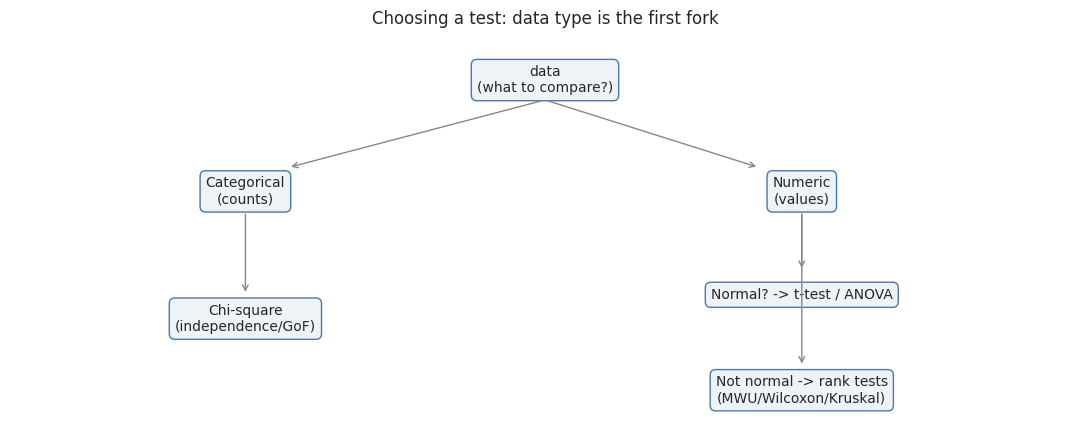

In [3]:
# [C3] [도식] 검정 선택 흐름 — 데이터 타입이 첫 갈림길
fig, ax = plt.subplots(figsize=(11, 4.5))                         # 그래프 하나를 그릴 도화지 준비
ax.axis("off")
boxes = {
    "data\n(what to compare?)": (0.5, 0.88),
    "Categorical\n(counts)":   (0.22, 0.60),
    "Numeric\n(values)":       (0.74, 0.60),
    "Chi-square\n(independence/GoF)": (0.22, 0.28),
    "Normal? -> t-test / ANOVA": (0.74, 0.34),
    "Not normal -> rank tests\n(MWU/Wilcoxon/Kruskal)": (0.74, 0.10),
}
for txt, (x, y) in boxes.items():
    ax.annotate(txt, (x, y), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.4", fc="#eef3f8", ec="#4a78a8"))
for x0, y0, x1, y1 in [(0.5,0.83,0.26,0.66),(0.5,0.83,0.7,0.66),
                       (0.22,0.55,0.22,0.34),(0.74,0.55,0.74,0.40),(0.74,0.55,0.74,0.16)]:
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="->", color="#888"))
ax.set_title("Choosing a test: data type is the first fork")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

> **읽는 법(그림):** 첫 갈림길은 **데이터 타입**입니다. *범주형(개수)*이면 카이제곱으로, *연속형(값)*이면 정규성을 따져 모수(t-test·ANOVA) 또는 비모수(순위 검정)로 갑니다. 오늘은 이 지도의 *왼쪽(카이제곱)*과 *오른쪽 아래(비모수)*를 채웁니다.

> 📌 **다른 산업에서는?** 이 "데이터 특성 → 도구" 사고는 마케팅(클릭=범주 → 카이제곱), 헬스케어(치료 반응=범주 → 카이제곱 / 비정규 수치 → 비모수), 제조(불량=범주, 수명=비정규) 어디서나 똑같이 작동합니다.

## 🚦 짚고 넘어가기 — Part 3 검정 선택 지도

1. 검정을 고를 때 가장 먼저 던지는 질문 두 가지는 무엇인가요?
2. 데이터가 "생존/사망" 같은 범주형이면 어떤 계열의 검정으로 가나요?
3. 연속형인데 정규성이 깨졌다면, 모수와 비모수 중 무엇을 고르나요?

> 💡 **다음 Part 예고:** 지도의 왼쪽 — **카이제곱 검정**부터 시작합니다. "두 범주가 서로 관련 있는가?"를 빈도로 따지는 법을 배웁니다.

# Part 4. 카이제곱 검정 — 두 범주는 서로 관련이 있나

타이타닉에서 "성별과 생존은 관련이 있었을까?"를 묻고 싶습니다. 둘 다 범주형이라 평균을 낼 수 없습니다. 대신 **표(분할표)에 개수를 세어** 따집니다.

> ❓ **이 파트에서 답할 질문:** 두 범주형 변수(예: 성별·생존)가 서로 관련 있는지, 개수만으로 어떻게 판정할까요?

## 💡 쉽게 말하면 — 관련이 없다면 몇 명이어야 하나

"성별과 생존이 **관련 없다**(독립이다)"고 가정하면, 생존율은 남녀가 같아야 합니다. 그 가정 아래 *기대되는 개수*(기대빈도 $E$)를 계산하고, *실제 개수*(관측빈도 $O$)와 얼마나 어긋나는지 봅니다. **많이 어긋날수록 "관련 있다"는 증거**가 됩니다.

## 카이제곱 통계량과 가정

관측빈도 $O$와 기대빈도 $E$의 어긋남을 칸마다 재서 더합니다.

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

- $O$: 각 칸에서 실제로 센 개수
- $E$: "두 변수가 독립이라면" 기대되는 개수 = (행 합 × 열 합) / 전체
- 자유도(df) = (행 수 − 1) × (열 수 − 1)

$\chi^2$가 크면(=어긋남이 크면) p가 작아지고, "독립이다"라는 귀무가설을 기각합니다.

<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Chi-square_pdf.svg" width="620" alt="Chi-square pdf.svg">

자유도(k)에 따른 카이제곱 분포. 제곱을 더한 값이라 **항상 0 이상**이고 오른쪽 꼬리가 깁니다. 자유도가 커질수록 봉우리가 오른쪽으로 이동합니다. p값은 관측된 $\chi^2$보다 **오른쪽 꼬리 면적**입니다.

> 🖼️ **그림 출처** — Wikimedia Commons, `Chi-square pdf.svg` (CC BY 3.0) · 원본·라이선스 상세: https://commons.wikimedia.org/wiki/File:Chi-square_pdf.svg

> 💡 **왜 오른쪽 꼬리만 보나요?** $\chi^2$는 "어긋남의 총합"이라 *클수록* 독립 가정이 의심스럽습니다. 값이 작다는 건 "관측이 기대와 잘 맞는다"는 뜻이니 기각할 이유가 없습니다. 그래서 카이제곱 검정은 늘 단측(오른쪽)입니다 — t 검정의 양측/단측 고민이 없습니다.

> ⚠️ **가정 — 기대빈도:** 각 칸의 **기대빈도가 5 이상**이어야 카이제곱 근사가 안정적입니다. 작은 표에서 이 조건이 깨지면 **Fisher 정확검정**(`scipy.stats.fisher_exact`)을 씁니다.

## 카이제곱은 '놀라움'을 숫자로 바꾼다

수식 $\chi^2 = \sum (O-E)^2 / E$ 를 한 번 더 음미해볼까요. 왜 이렇게 생겼는지 알면 결과 해석이 훨씬 쉬워집니다.

먼저 **$O-E$**, 즉 "관측 − 기대"는 *각 칸이 기대에서 얼마나 벗어났는가*입니다. 독립이라면(관련 없다면) 관측이 기대와 비슷할 테니 이 값이 0에 가까울 겁니다. 그런데 그냥 더하면 양수와 음수가 상쇄돼 버립니다(어떤 칸은 기대보다 많고 어떤 칸은 적으니까요). 그래서 **제곱**해서 부호를 없애고 큰 어긋남을 더 크게 키웁니다 — 앞서 분산을 구할 때 편차를 제곱했던 것과 똑같은 발상입니다.

다음으로 **$E$로 나누는** 이유. 같은 '10명 차이'라도, 기대가 20명인 칸에서의 10명과 기대가 2,000명인 칸에서의 10명은 무게가 다릅니다. 작은 칸에서의 어긋남이 더 '놀라운' 일입니다. $E$로 나눠 *상대적인* 어긋남으로 바꾸는 겁니다.

이렇게 칸마다 계산한 '상대적 놀라움'을 모두 더한 게 $\chi^2$입니다. 값이 클수록 "독립이라면 이런 표는 좀처럼 안 나오는데?"라는 뜻이고, 그 '좀처럼'의 정도를 카이제곱 분포에 비춰 p로 환산합니다. 자유도(df)는 '표가 자유롭게 변할 수 있는 칸 수'로, 행·열의 합이 고정됐을 때 독립적으로 정해지는 칸의 개수입니다. 그래서 $2 \times 2$ 표의 자유도는 $(2-1)(2-1)=1$입니다. 이제 직접 계산해봅시다.

## 예제 · 성별 × 생존 분할표와 카이제곱 검정

In [4]:
# [C4] 1) 분할표(교차표) 만들기 — 성별 × 생존
ct = pd.crosstab(titanic["sex"], titanic["survived"])             # 분할표(교차표) — 두 범주의 조합별 개수를 셈
ct.columns = ["사망(0)", "생존(1)"]
print("관측빈도 (성별 × 생존):")
print(ct)
print()

# 2) 카이제곱 독립성 검정 - chi2 = 카이제곱 통계량
chi2, p, dof, expected = stats.chi2_contingency(ct)               # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print(f"chi2 = {chi2:.2f},  df = {dof},  p = {p:.2e}")
print()
print("기대빈도 E (독립이라면 기대되는 개수):")
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

관측빈도 (성별 × 생존):
        사망(0)  생존(1)
sex                 
female     81    233
male      468    109

chi2 = 260.72,  df = 1,  p = 1.20e-58

기대빈도 E (독립이라면 기대되는 개수):
        사망(0)  생존(1)
sex                 
female  193.5  120.5
male    355.5  221.5


> **읽는 법:** p가 사실상 0입니다 — "성별과 생존은 독립"이라는 가정을 강하게 기각합니다. 기대빈도와 관측빈도를 비교하면, 여성의 *생존* 관측치가 기대보다 훨씬 많고 남성은 그 반대입니다. "여성과 어린이 먼저"가 데이터로 드러납니다.

## 그림으로 · 관측빈도 vs 기대빈도

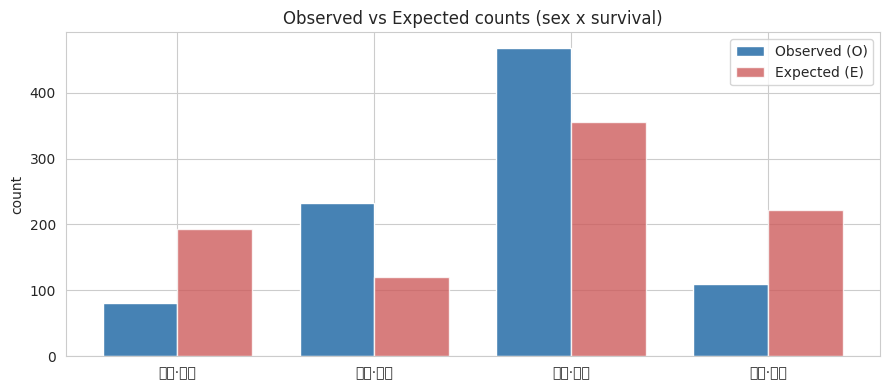

In [5]:
# [C5] [도식] 관측빈도 vs 기대빈도 — 어긋남이 클수록 연관이 강하다
import matplotlib as mpl
mpl.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
mpl.rcParams["axes.unicode_minus"] = False      # 음수 눈금의 − 기호 깨짐 방지

labels = ["여성·사망", "여성·생존", "남성·사망", "남성·생존"]
obs = ct.values.flatten()
exp = expected.flatten()
x = np.arange(len(labels)); w = 0.38                              # 정수 눈금 배열 생성
fig, ax = plt.subplots(figsize=(9, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.bar(x - w/2, obs, w, label="Observed (O)", color="steelblue")
ax.bar(x + w/2, exp, w, label="Expected (E)", color="indianred", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("count")
ax.set_title("Observed vs Expected counts (sex x survival)"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

> **읽는 법(그림):** 파랑(관측)과 빨강(기대)의 막대 높이가 칸마다 크게 다릅니다. 이 *어긋남의 총합*이 곧 $\chi^2$입니다. 막대가 거의 같았다면 "독립"이라 $\chi^2$가 작았을 겁니다.

## 독립성에서 적합도로 — 같은 도구, 다른 질문

지금까지는 *두* 범주형 변수의 관계(성별 × 생존)를 봤습니다. 그런데 카이제곱은 변수가 *하나*일 때도 쓸 수 있습니다. "이 한 범주의 분포가 내가 기대한 모양과 맞는가?"를 묻는 **적합도 검정(Goodness-of-Fit)**입니다.

원리는 똑같습니다 — 관측빈도 $O$와 기대빈도 $E$의 어긋남을 $\sum (O-E)^2/E$로 잽니다. 다른 건 *기대빈도를 어디서 가져오느냐*뿐입니다. 독립성 검정에서는 '두 변수가 독립이라면'이라는 가정에서 기대빈도를 계산했지만, 적합도 검정에서는 *내가 직접 세운 기준 분포*(예: "모든 항구에서 똑같이 탔을 것이다 = 균등분포")에서 가져옵니다.

이 검정은 생각보다 쓸모가 많습니다. 주사위가 공정한지(각 눈이 1/6씩 나오나), 요일별 매출이 고른지, 고객이 예상한 비율대로 등급에 분포하는지, 설문 응답이 기대 분포를 따르는지 — 모두 "한 범주의 분포가 기대와 맞나?"라는 같은 질문입니다. 아래에서 타이타닉 탑승 항구가 균등하게 분포하는지 확인해봅니다.

## 예제 · 적합도 검정 — 탑승 항구는 균등한가

In [6]:
# [C6] 적합도 검정(goodness-of-fit) — "한 범주의 분포가 기대와 맞나?"
# 예: 탑승 항구(embarked) 분포가 균등(1/3씩)하다고 볼 수 있나?
emb = titanic["embarked"].dropna().value_counts()                 # 결측(NaN) 제거
expected_uniform = [emb.sum() / len(emb)] * len(emb)   # 균등 기대
stat, p_gof = stats.chisquare(f_obs=emb.values, f_exp=expected_uniform)  # 카이제곱 적합도 검정 — 관측이 기대 비율과 맞나
print("항구별 관측 인원:"); print(emb)
print(f"\n적합도 검정: chi2 = {stat:.1f}, p = {p_gof:.2e}")
print("→ p가 매우 작으니 '균등 분포'라는 가정은 기각 — 항구마다 탑승 인원이 크게 다릅니다.")

항구별 관측 인원:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

적합도 검정: chi2 = 625.8, p = 1.28e-136
→ p가 매우 작으니 '균등 분포'라는 가정은 기각 — 항구마다 탑승 인원이 크게 다릅니다.


**독립성 vs 적합도 — 무엇이 다른가요?**

| 구분 | 묻는 것 | 표 모양 |
|------|---------|---------|
| **독립성 검정** | 두 범주형 변수가 *서로 관련* 있나 | 2차원 분할표 (행×열) |
| **적합도 검정** | 한 범주형의 분포가 *기대와 맞나* | 1차원 빈도 (한 줄) |

> 📌 **다른 산업에서는?** 독립성 검정은 마케팅(캠페인 × 전환), 의료(치료군 × 회복)에서, 적합도 검정은 품질관리(불량 유형이 예상 비율대로인가), 주사위·룰렛의 공정성 검증 등에 쓰입니다.

## 예제 · 객실 등급 × 생존 + 생존율 시각화

등급 × 생존: chi2 = 102.9, df = 2, p = 4.55e-23


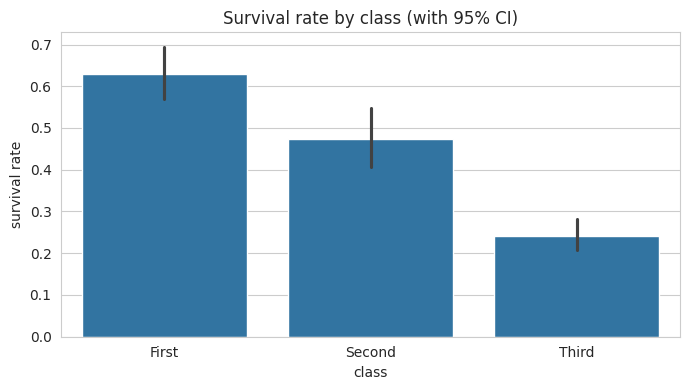

In [7]:
# [C7] 또 다른 독립성 예 — 객실 등급(class) × 생존, seaborn으로 한눈에
ct2 = pd.crosstab(titanic["class"], titanic["survived"])          # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2_2, p2, dof2, _ = stats.chi2_contingency(ct2)                 # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print(f"등급 × 생존: chi2 = {chi2_2:.1f}, df = {dof2}, p = {p2:.2e}")

# 생존율(비율)을 집단 비교로 시각화 — 이해 후 탐색이므로 seaborn 사용
fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.barplot(data=titanic, x="class", y="survived", ax=ax,         # 집단별 평균 막대 + 신뢰구간 오차선
            order=["First", "Second", "Third"], errorbar=("ci", 95))
ax.set_ylabel("survival rate"); ax.set_title("Survival rate by class (with 95% CI)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

> **읽는 법(그림):** 1등석 → 3등석으로 갈수록 생존율이 뚜렷이 낮아집니다. 카이제곱 p도 사실상 0이라, "등급과 생존은 무관"이라는 가정을 기각합니다. 막대 위 오차선은 95% 신뢰구간(앞서 배운 그 도구!)입니다.

## 기대빈도는 어디서 나오나 — 손으로 따라가기

기대빈도 $E$는 "두 변수가 **독립이라면** 이 칸에 몇 명이 있어야 하나"입니다. 공식은 의외로 단순합니다.

$$E_{ij} = \frac{(\text{행 }i\text{ 합}) \times (\text{열 }j\text{ 합})}{\text{전체}}$$

예를 들어 전체 891명 중 여성이 314명, 생존자가 342명이라면, "여성·생존" 칸의 기대빈도는 $314 \times 342 / 891 \approx 120.5$명입니다. 실제 관측치가 이보다 훨씬 많다면(여성 생존이 기대보다 많다면) 그 칸이 "독립이 아니다"라는 증거를 보탭니다.

In [8]:
# [C8] 표준화 잔차 — 어느 칸이 연관을 '만드는지' 짚어준다
ct = pd.crosstab(titanic["sex"], titanic["survived"])             # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2, p, dof, expected = stats.chi2_contingency(ct)               # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
resid = (ct.values - expected) / np.sqrt(expected)   # (O-E)/sqrt(E)
resid_df = pd.DataFrame(resid, index=ct.index, columns=["사망", "생존"]).round(2)
print("표준화 잔차 (|값| > 2 이면 그 칸이 연관에 크게 기여):")
print(resid_df)
print("\n→ 여성·생존(+)과 남성·사망(+)이 큰 양수, 즉 '기대보다 많다'가 연관의 정체입니다.")

표준화 잔차 (|값| > 2 이면 그 칸이 연관에 크게 기여):
          사망     생존
sex                
female -8.09  10.25
male    5.97  -7.56

→ 여성·생존(+)과 남성·사망(+)이 큰 양수, 즉 '기대보다 많다'가 연관의 정체입니다.


> **읽는 법:** 표준화 잔차는 각 칸이 "기대에서 얼마나, 어느 방향으로" 벗어났는지를 표준화한 값입니다. 절댓값이 2를 넘으면 그 칸이 연관을 강하게 만든 곳입니다. 카이제곱이 "관련 있다"고만 말한다면, 잔차는 "*어디서* 관련이 생겼나"를 짚어줍니다.

## 연관의 세기 — Cramér's V (효과 크기)

카이제곱 p는 "관련 있나(존재)"를 말할 뿐, "*얼마나* 강한가(크기)"는 말하지 않습니다. 표본이 크면 사소한 연관도 유의하게 나오죠(앞서 본 그 교훈!). 그래서 **Cramér's V**라는 효과 크기를 함께 봅니다(0~1, 클수록 강한 연관).

$$V = \sqrt{\frac{\chi^2}{n \times (\min(\text{행},\text{열}) - 1)}}$$

In [9]:
# [C9] Cramér's V 계산 — 연관의 '세기'
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]                   # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
    n = confusion.values.sum()
    k = min(confusion.shape) - 1
    return np.sqrt(chi2 / (n * k))

v_sex   = cramers_v(pd.crosstab(titanic["sex"],   titanic["survived"]))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈
v_class = cramers_v(pd.crosstab(titanic["class"], titanic["survived"]))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈
print(f"성별 × 생존  Cramér's V = {v_sex:.3f}  (강함)")
print(f"등급 × 생존  Cramér's V = {v_class:.3f}  (중간)")
print("기준(2x2): 0.1 작음 · 0.3 중간 · 0.5 큼")

성별 × 생존  Cramér's V = 0.541  (강함)
등급 × 생존  Cramér's V = 0.340  (중간)
기준(2x2): 0.1 작음 · 0.3 중간 · 0.5 큼


> **읽는 법:** 성별 × 생존의 V가 등급 × 생존보다 큽니다 — 둘 다 유의하지만, *성별*이 생존과 더 강하게 연관됐다는 뜻입니다. p(유의성)와 V(세기)를 함께 보고하는 습관은 앞서 배운 "p + 효과 크기"와 정확히 같은 원리입니다.

## ⌨️ 백문이 불여일타! (1) — embarked × survived 카이제곱

```
[문제]
1) 타이타닉에서 탑승 항구(embarked) × 생존(survived) 분할표를 만들어보세요.
2) 카이제곱 독립성 검정을 수행해보세요.
3) p < 0.05 인지 확인하고, 두 변수가 관련 있는지 결론을 한 줄로 적어보세요.
```

In [26]:
# [C10] ⌨️ 백문이 불여일타! (1) — embarked × survived 카이제곱 독립성 검정

# 1. 탑승 항구 × 생존 분할표
ct_embarked = pd.crosstab(titanic["embarked"], titanic["survived"])
ct_embarked.columns = ["사망(0)", "생존(1)"]
print("관측빈도 (탑승 항구 × 생존):")
print(ct_embarked)

# 자유도에서 각 행/열 값 -1을 빼는 이유는 마지막 행/열 정보는 정해진 행/열의 합계 때문에 자동 결정되니까 자유롭지 않다는 의미임.

# 2. 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(ct_embarked)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.2e}")
print("\n기대빈도 E (독립이라면 기대되는 개수):")
print(pd.DataFrame(expected, index=ct_embarked.index, columns=ct_embarked.columns).round(2))

# 관측된 p-값은 0에 가까우므로 두 변수는 독립적으로 볼 수 없으며, 즉 항구별 생존율 차이가 우연으로 설명되지 않음.
# 항구별 차이는 Cramér's V를 통해 효과크기에 대한 추가 분석이 필요함.

관측빈도 (탑승 항구 × 생존):
          사망(0)  생존(1)
embarked              
C            75     93
Q            47     30
S           427    217

chi2 = 26.49, df = 2, p = 1.77e-06

기대빈도 E (독립이라면 기대되는 개수):
           사망(0)   생존(1)
embarked                
C         103.75   64.25
Q          47.55   29.45
S         397.70  246.30


<details>
<summary>(클릭) 💡 힌트</summary>

- 분할표는 `pd.crosstab(titanic["embarked"], titanic["survived"])`로 만듭니다 — [C4]에서 성별 × 생존에 썼던 그 방법입니다.
- `stats.chi2_contingency(분할표)`는 `chi2`·`p`·자유도·기대빈도를 한 번에 돌려줍니다.
- 반환된 `p`를 0.05와 비교해 "관련 있다 / 독립으로 볼 수 있다" 중 하나로 결론을 적어보세요.

</details>

## 🚦 짚고 넘어가기 — Part 4 카이제곱 검정

1. 카이제곱 통계량 $\chi^2 = \sum (O-E)^2 / E$ 에서 $O$와 $E$는 각각 무엇인가요?
2. 독립성 검정과 적합도 검정의 차이는 무엇인가요?
3. 기대빈도가 5보다 작은 칸이 많으면 어떤 검정을 대신 쓰나요?

> 💡 **다음 Part 예고:** 카이제곱은 "관련 있다"까지 말해줍니다. 그런데 "*여성이라서* 생존 확률이 얼마였나?"를 직접 구하려면 **조건부확률**이 필요합니다. Part 5로 갑니다.

# Part 5. 조건부확률과 베이즈 정리 — "이미 일어난 일"의 확률

카이제곱이 "성별과 생존은 관련 있다"고 알려줬습니다. 이제 한 걸음 더 — "**여성이라는 걸 알 때** 생존 확률은 얼마인가?" 같은 *조건부* 질문에 답해봅시다.

> ❓ **이 파트에서 답할 질문:** "B가 일어났다는 걸 알 때 A의 확률"은 어떻게 구하고, 그 방향을 뒤집으면 무슨 일이 벌어질까요?

## 💡 쉽게 말하면 — 조건이 붙으면 확률이 갱신된다

그냥 "생존 확률"과 "*여성인* 사람의 생존 확률"은 다릅니다. 후자는 **조건이 붙은** 확률, 즉 조건부확률입니다. 정보(성별)를 알면 확률이 갱신되는 겁니다. 베이즈 정리는 이 갱신을 *거꾸로*도 할 수 있게 해줍니다 — "생존한 사람이 여성일 확률"처럼요.

## 정의 — 조건부확률과 베이즈 정리

**조건부확률:** $B$가 일어났을 때 $A$의 확률

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

**베이즈 정리:** 조건의 방향을 뒤집는 공식

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}$$

- $P(A)$ : 사전확률 (B를 알기 전 A의 확률)
- $P(A \mid B)$ : 사후확률 (B를 알고 난 뒤 갱신된 A의 확률)
- 베이즈는 구하기 어려운 $P(A \mid B)$를, 구하기 쉬운 $P(B \mid A)$로 바꿔줍니다.

## 베이즈가 알려주는 사고방식 — 믿음을 갱신한다

베이즈 정리는 공식이기 전에 하나의 *태도*입니다. **"새로운 증거를 만나면 기존의 믿음을 그만큼 갱신한다"**는 태도입니다.

처음에 우리는 어떤 일에 대해 *사전확률*(prior)을 갖습니다 — 예컨대 "이 손님이 이탈할 확률은 평소 10% 정도"처럼요. 그러다 새 정보(증거)를 얻습니다 — "최근 3개월 접속이 없다." 베이즈는 이 증거를 반영해 확률을 *사후확률*(posterior)로 갱신합니다. 핵심은, 증거가 아무리 강해도 **사전확률을 완전히 무시하지는 않는다**는 점입니다. 곧 볼 질병 검사 예제가 정확히 이것입니다 — 검사(증거)가 꽤 정확해도, '이 병은 드물다'는 사전확률 때문에 사후확률은 17%에 그칩니다.

이 사고가 특히 중요한 곳이 *희귀한 사건*입니다. 사기 거래, 심각한 질병, 보안 침해처럼 *원래 드문 일*은, 탐지기가 꽤 정확해도 '경보'의 대부분이 오탐이 되기 쉽습니다(정상이 압도적으로 많으니까요). 그래서 "정확도 99%!"라는 말에 곧장 속지 않고 *"그 일이 원래 얼마나 흔한가(사전확률)"*를 함께 묻는 습관 — 이게 데이터를 다루는 사람의 기본기입니다. 카이제곱이 '두 범주가 연관됐나'를 본다면, 베이즈는 '그 연관을 알 때 확률이 어떻게 바뀌나'를 보는 한 걸음 더 들어간 시선입니다.

In [10]:
# [C11] titanic으로 조건부확률 직접 계산
p_survive          = titanic["survived"].mean()
p_survive_female   = titanic.loc[titanic["sex"] == "female", "survived"].mean()
p_survive_male     = titanic.loc[titanic["sex"] == "male",   "survived"].mean()
p_female           = (titanic["sex"] == "female").mean()

print(f"P(생존)             = {p_survive:.3f}")
print(f"P(생존 | 여성)      = {p_survive_female:.3f}")
print(f"P(생존 | 남성)      = {p_survive_male:.3f}")
print()
# 베이즈로 방향 뒤집기: P(여성 | 생존) = P(생존|여성) P(여성) / P(생존)
p_female_given_survive = p_survive_female * p_female / p_survive
print(f"P(여성 | 생존)      = {p_female_given_survive:.3f}  (베이즈 정리로 계산)")
# 검산: 직접 세어도 같은지
check = (titanic.loc[titanic["survived"] == 1, "sex"] == "female").mean()
print(f"직접 센 값          = {check:.3f}  ← 일치 확인")


# 읽는 법: 세로 줄 | 뒤가 분모
# P(생존∣여성) → 여성만 모아 놓고, 그중 생존자 비율
# P(여성∣생존) → 생존자만 모아 놓고, 그중 여성 비율

P(생존)             = 0.384
P(생존 | 여성)      = 0.742
P(생존 | 남성)      = 0.189

P(여성 | 생존)      = 0.681  (베이즈 정리로 계산)
직접 센 값          = 0.681  ← 일치 확인


> **읽는 법:** 전체 생존율은 약 38%지만, *여성이라는 조건*이 붙으면 74%로 뜁니다 — 정보가 확률을 갱신합니다. 베이즈로 방향을 뒤집으면 "생존자 중 여성 비율"이 나오고, 직접 센 값과 정확히 일치합니다. 베이즈 정리가 마법이 아니라 *정의의 재배열*임을 보여줍니다.

## 베이즈의 반직관 — 질병 검사 이야기

베이즈 정리가 빛나는 고전 예제입니다. 어떤 병의 유병률이 **1%**, 검사의 민감도(병이 있을 때 양성)가 **99%**, 특이도(병이 없을 때 음성)가 **95%**라고 합시다. 검사에서 **양성**이 나왔다면, 실제로 병에 걸렸을 확률은 얼마일까요? 직관적으로는 "99% 아냐?" 싶지만, 계산해봅시다.

### 📖 먼저 네 낱말 — 민감도·특이도·양성예측도·음성예측도

| 용어 | 정의 | 무엇을 묻나 |
| --- | --- | --- |
| **민감도(Sensitivity)** | $P(\text{양성} \mid \text{질병})$ | 병이 있는 사람을 얼마나 잘 찾아내나 |
| **특이도(Specificity)** | $P(\text{음성} \mid \text{정상})$ | 건강한 사람을 얼마나 잘 통과시키나 |
| **양성예측도(PPV)** | $P(\text{질병} \mid \text{양성})$ | **양성이 나온 사람이 실제로 병일 확률** |
| **음성예측도(NPV)** | $P(\text{정상} \mid \text{음성})$ | 음성이 나온 사람이 실제로 건강할 확률 |

<img src="https://upload.wikimedia.org/wikipedia/commons/1/17/PPV%2C_NPV%2C_Sensitivity_and_Specificity.svg" width="620" alt="PPV, NPV, Sensitivity and Specificity.svg">

네 지표가 분할표의 어느 방향을 보는지 정리한 그림. **민감도·특이도는 '열' 방향**(진짜 상태를 조건으로), **PPV·NPV는 '행' 방향**(검사 결과를 조건으로) 계산합니다. 방향이 다르므로 값도 전혀 달라집니다.

> 🖼️ **그림 출처** — Wikimedia Commons, `PPV, NPV, Sensitivity and Specificity.svg` (CC BY-SA 4.0) · 원본·라이선스 상세: https://commons.wikimedia.org/wiki/File:PPV,_NPV,_Sensitivity_and_Specificity.svg

> 💡 **핵심:** 검사 성능표에 적힌 것은 보통 *민감도·특이도*이지만, 검사받은 사람이 알고 싶은 것은 *PPV*입니다. 이 둘을 잇는 다리가 바로 **베이즈 정리**이고, 다리를 건널 때 반드시 필요한 재료가 **유병률(사전확률)** 입니다.

## 예제 · 베이즈 정리로 P(질병 | 양성) 계산하기

In [11]:
# [C12] 베이즈 정리 — 양성일 때 실제 질병 확률 P(질병 | 양성)
prevalence  = 0.01    # P(질병) 유병률
sensitivity = 0.99    # P(양성 | 질병)
specificity = 0.95    # P(음성 | 정상)  →  P(양성 | 정상) = 1 - 0.95

p_pos_given_disease = sensitivity
p_pos_given_healthy = 1 - specificity
# 전체 양성 확률 P(양성) = 민감도·유병 + 오탐·비유병
p_positive = p_pos_given_disease * prevalence + p_pos_given_healthy * (1 - prevalence)
p_disease_given_pos = p_pos_given_disease * prevalence / p_positive

print(f"P(양성)            = {p_positive:.4f}")
print(f"P(질병 | 양성)     = {p_disease_given_pos:.3f}  ({p_disease_given_pos*100:.1f}%)")
print("→ 양성인데도 실제 질병 확률은 약 17%뿐! 유병률이 낮으면 오탐이 진짜를 압도합니다.")

P(양성)            = 0.0594
P(질병 | 양성)     = 0.167  (16.7%)
→ 양성인데도 실제 질병 확률은 약 17%뿐! 유병률이 낮으면 오탐이 진짜를 압도합니다.


> **읽는 법:** 검사 정확도가 99%여도, 병 자체가 드물면(1%) 양성의 대부분이 *건강한 사람의 오탐*입니다. 그래서 사후확률은 17% 수준에 그칩니다. **사전확률(유병률)을 무시하면 안 된다**는 베이즈의 교훈입니다.

> 📌 **다른 산업에서는?** 스팸 필터(이 단어가 있을 때 스팸일 확률), 사기 탐지(이 패턴일 때 사기 확률), 추천 시스템 등은 모두 베이즈식 확률 갱신으로 작동합니다.

## 베이즈를 그림으로 — 자연빈도 나무

확률(0.01, 0.99…)로 들으면 헷갈리지만, **사람 수**로 바꾸면 또렷해집니다. 위 질병 검사 예제를 *10,000명*으로 펼쳐보겠습니다. 이렇게 사람 수로 푸는 방식을 "자연빈도(Natural Frequency)" 접근이라고 합니다.

아래는 같은 발상을 담은 고전적인 도식입니다(약물 검사 예). 확률을 곱하지 않고 *사람 수를 따라 내려가면* 답이 바로 보입니다.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/88/Bayes_theorem_drugs_example_tree.svg" width="640" alt="Bayes theorem drugs example tree.svg">

자연빈도 나무의 예 — 전체 인원을 '진짜 상태'로 먼저 나누고, 각 갈래에서 검사 결과로 다시 나눕니다. 맨 아래 '양성' 칸들을 모아 그중 진짜 양성의 비율을 세면 그것이 바로 사후확률(PPV)입니다.

> 🖼️ **그림 출처** — Wikimedia Commons, `Bayes theorem drugs example tree.svg` (CC0) · 원본·라이선스 상세: https://commons.wikimedia.org/wiki/File:Bayes_theorem_drugs_example_tree.svg

> 💡 아래 셀에서 우리 예제(유병률 1%, 민감도 99%, 특이도 95%)를 같은 방식으로 직접 그려봅니다.

양성 판정 총원 = 594명 중 진짜 질병은 99명 → 16.7%


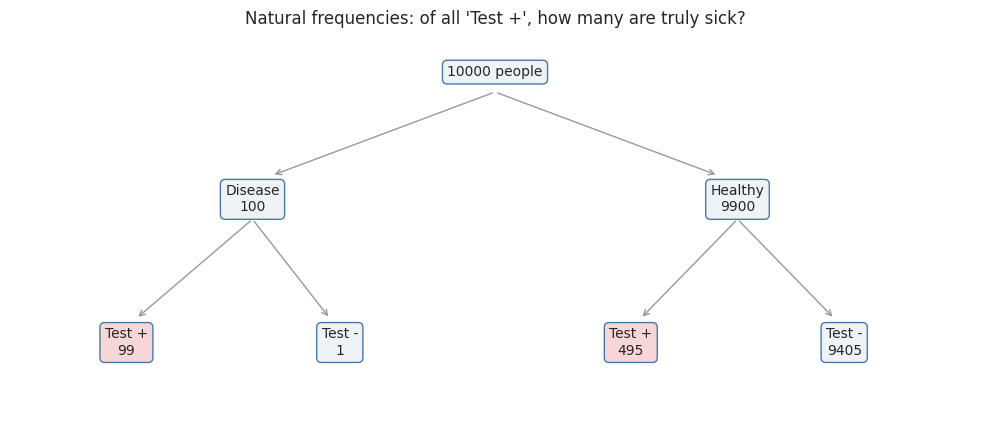

In [12]:
# [C13] [도식] 자연빈도 나무 — 10,000명으로 베이즈 직관 잡기
N = 10000
prev, sens, spec = 0.01, 0.99, 0.95
disease = int(N * prev); healthy = N - disease        # 질병 100 / 건강 9900
tp = int(disease * sens); fn = disease - tp           # 진양성 99 / 위음성 1
fp = int(healthy * (1 - spec)); tn = healthy - fp     # 위양성 495 / 진음성 9405

fig, ax = plt.subplots(figsize=(10, 4.5)); ax.axis("off")         # 그래프 하나를 그릴 도화지 준비
nodes = {f"{N} people": (0.5, 0.9),
         f"Disease\n{disease}": (0.25, 0.58), f"Healthy\n{healthy}": (0.75, 0.58),
         f"Test +\n{tp}": (0.12, 0.22), f"Test -\n{fn}": (0.34, 0.22),
         f"Test +\n{fp}": (0.64, 0.22), f"Test -\n{tn}": (0.86, 0.22)}
for txt, (x, y) in nodes.items():
    fc = "#f6d6d6" if "Test +" in txt else "#eef3f8"
    ax.annotate(txt, (x, y), ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.35", fc=fc, ec="#4a78a8"))
for x0, y0, x1, y1 in [(0.5,0.85,0.27,0.64),(0.5,0.85,0.73,0.64),
                       (0.25,0.53,0.13,0.28),(0.25,0.53,0.33,0.28),
                       (0.75,0.53,0.65,0.28),(0.75,0.53,0.85,0.28)]:
    ax.annotate("", (x1, y1), (x0, y0), arrowprops=dict(arrowstyle="->", color="#999"))
ax.set_title("Natural frequencies: of all 'Test +', how many are truly sick?")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(f"양성 판정 총원 = {tp+fp}명 중 진짜 질병은 {tp}명 → {tp/(tp+fp):.1%}")


# 기호	        읽는 법	                              뜻
#  U               U            실제로 해당 상태임(이 그림 원본에서는 약물 사용자)
#  U               ˉ            U가 아님	실제로 해당 상태가 아님
#  +	          양성	        검사 결과 양성
#  −	          음성	        검사 결과 음성
# P(U)	        U일 확률	        전체 중 실제 해당 상태인 비율
# P(+∣U)   U일 때 양성일 확률	실제 해당 상태인 사람에게서 양성이 나올 확률
# P(U∩+)   U이면서 양성일 확률	실제 해당 상태이고 동시에 검사도 양성인 비율

> **읽는 법(그림):** 양성 판정을 받은 사람은 모두 **진양성 99 + 위양성 495 = 594명**입니다. 이 중 진짜 환자는 99명뿐 — 약 17%죠. "건강한 사람이 워낙 많아서(9,900명) 그중 5%의 오탐만으로도 진짜 환자 수를 압도한다"가 한눈에 보입니다. 확률을 사람 수로 바꾸면 베이즈가 직관이 됩니다.

> 📌 **다른 산업에서는?** 자연빈도 사고는 사기 탐지(거래 대부분이 정상이라 '사기 알림'의 상당수가 오탐), 품질검사, 보안 경보(알림 피로) 등 *드문 사건을 탐지*하는 모든 곳의 핵심 함정을 설명합니다.

## ⌨️ 백문이 불여일타! (2) — P(생존|1등석)과 P(1등석|생존)

```
[문제]
1) titanic에서 P(생존 | 1등석)을 구해보세요.
2) P(1등석 | 생존)도 구해보세요.
3) 두 값이 왜 다른지 주석으로 한 줄 적어보세요.
```

In [27]:
# [C14] ⌨️ 백문이 불여일타! (2) — P(생존|1등석)과 P(1등석|생존) 계산

# 1. P(생존 | 1등석)
p_survived_given_first = titanic.loc[titanic["pclass"] == 1, "survived"].mean()

# 2. P(1등석 | 생존)
p_first_given_survived = (titanic.loc[titanic["survived"] == 1, "pclass"] == 1).mean()

print(f"P(생존 | 1등석) = {p_survived_given_first:.4f} ({p_survived_given_first:.1%})")
print(f"P(1등석 | 생존) = {p_first_given_survived:.4f} ({p_first_given_survived:.1%})")

P(생존 | 1등석) = 0.6296 (63.0%)
P(1등석 | 생존) = 0.3977 (39.8%)


<details>
<summary>(클릭) 💡 힌트</summary>

- 조건부확률은 "조건 집단으로 행을 먼저 좁힌 뒤 비율을 구한다"입니다 — 불리언 마스크 `titanic["class"] == "First"`로 시작해보세요.
- `survived` 컬럼은 0/1이므로 `.mean()`이 곧 생존 비율입니다 — [C11]에서 본 그 기법입니다.
- P(1등석 | 생존)은 [C12]의 베이즈 정리로 방향을 뒤집어 구할 수 있습니다. 두 값의 분모(기준 집단)가 무엇인지 비교해보세요.

</details>

## 🚦 짚고 넘어가기 — Part 5 조건부확률·베이즈

1. $P(A \mid B)$와 $P(B \mid A)$는 왜 일반적으로 다른가요?
2. 베이즈 정리에서 사전확률과 사후확률은 각각 무엇인가요?
3. 질병 검사 예제에서 사후확률이 낮게 나온 핵심 이유는 무엇이었나요?

> 💡 **다음 Part 예고:** 다시 연속형 데이터로 돌아갑니다. 단, *정규성이 깨진* 데이터입니다. 평균 대신 **순위**로 비교하는 비모수 검정을 Part 6에서 배웁니다.

# Part 6. 비모수 검정 3종 — 정규성이 깨지면 순위로

결제 금액이나 응답 시간처럼 한쪽으로 쏠린 데이터는 평균이 휘둘립니다(이상치 한 명이 평균을 끌어올립니다). 이럴 때는 값 대신 **순위(등수)**로 비교하는 비모수 검정을 씁니다.

> ❓ **이 파트에서 답할 질문:** 정규성 가정이 깨진 데이터에서 집단 차이는 무엇으로, 어떻게 검정할까요?

## 💡 쉽게 말하면 — 기록이 아니라 등수로 견주기

달리기 기록을 비교할 때 "초 단위 평균"이 아니라 "등수"로 견주는 것과 같습니다. 1등·2등·3등… 순위만 쓰면, 마지막 주자가 아무리 느려도(=극단적 이상치) 전체 비교가 흔들리지 않습니다. 비모수 검정은 이 **순위의 힘**을 빌립니다.

## 모수 검정과의 짝꿍 — 3종 세트

| 비모수 검정 | 대응하는 모수 검정 | 언제 |
|-------------|-------------------|------|
| **Mann-Whitney U** | 2표본 t-test | 두 *독립* 집단 비교 |
| **Wilcoxon 부호순위** | 대응표본 t-test | *짝지어진* 두 측정 비교 |
| **Kruskal-Wallis** | 일원 ANOVA | *세 집단 이상* 비교 |

> 비모수 검정은 평균이 아니라 **분포의 위치(중앙값 경향)**가 다른지를 봅니다. 가정이 적은 대신, 가정이 맞는다면 모수 검정보다 검정력이 약간 낮을 수 있습니다.

## 평균이 거짓말을 할 때 — 왜 순위로 갈아타는가

"한 가게의 손님 평균 결제액이 8만 원"이라고 하면 '꽤 비싼 곳'이라 생각할 겁니다. 그런데 알고 보니 손님 9명은 2만 원씩 쓰고 한 명이 60만 원을 썼다면? 평균 8만 원은 *아무도 대표하지 못하는* 숫자입니다. 이렇게 한쪽으로 길게 쏠린(우편향) 데이터에서는 **평균이 극단값 한두 개에 휘둘려** 집단의 '전형'을 왜곡합니다.

비모수 검정은 이 문제를 영리하게 피합니다. 값을 그대로 쓰지 않고 **전체를 한 줄로 세운 순위(등수)**로 바꾸기 때문입니다. 60만 원을 쓴 손님은 '1등'일 뿐, 그 값이 600만 원이어도 똑같이 '1등'입니다. 극단값이 등수 하나 이상으로 결과를 흔들 수 없습니다. 그래서 비모수 검정은 **이상치에 강하고(Robust) 분포 모양을 가정하지 않습니다.**

물론 공짜는 없습니다. 값을 순위로 바꾸며 "얼마나 차이 나는가"라는 *크기 정보*를 일부 버리기 때문에, 데이터가 *정말로* 정규분포를 따른다면 같은 표본에서 t-test보다 차이를 잡아내는 힘(검정력)이 살짝 약합니다. 그래서 선택의 원칙은 명확합니다 — **정규성이 그럴듯하면 모수 검정으로 효율을 취하고, 의심스러우면 비모수로 안전을 취한다.** 둘 다 돌려 같은 결론이 나오면 가장 든든합니다. '무엇이 정답이냐'가 아니라 '내 데이터에 무엇이 어울리느냐'를 묻는 겁니다. 먼저 tips 결제액이 정말 비정규인지 눈과 숫자로 확인해봅시다.

## 확인 · tips 결제액은 정말 비정규인가

Shapiro-Wilk (정규성): p = 3.32e-10  → p가 작으니 '정규분포 아님'


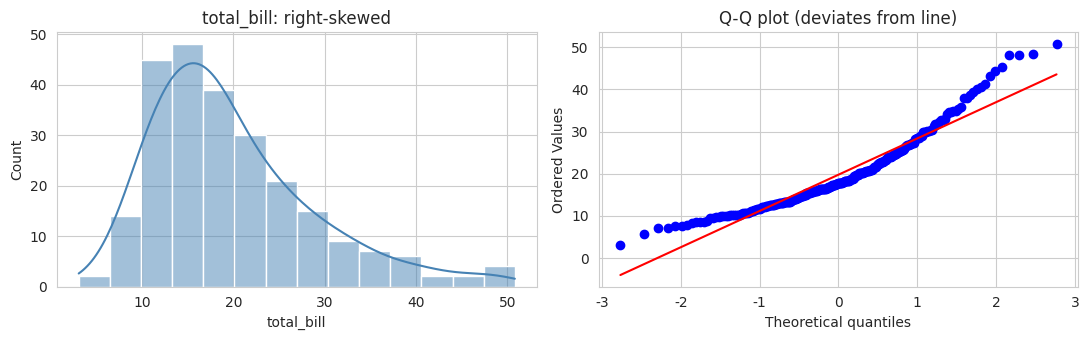

In [13]:
# [C15] 먼저 정규성부터 확인 — tips 결제액은 우편향(비정규)
bill = tips["total_bill"]
sw_stat, sw_p = stats.shapiro(bill)                               # 정규성 검정 — H0: 정규분포를 따른다
print(f"Shapiro-Wilk (정규성): p = {sw_p:.2e}  → p가 작으니 '정규분포 아님'")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))                 # 그림 한 장에 그래프 2개(1행 2열)
sns.histplot(bill, kde=True, ax=axes[0], color="steelblue")       # 히스토그램 — 값이 어디에 몰려 있나
axes[0].set_title("total_bill: right-skewed")
stats.probplot(bill, dist="norm", plot=axes[1])   # Q-Q plot
axes[1].set_title("Q-Q plot (deviates from line)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

> **읽는 법(그림):** 왼쪽 히스토그램은 오른쪽으로 긴 꼬리(우편향)를 보이고, 오른쪽 Q-Q plot은 점들이 직선에서 휘어 있습니다. 둘 다 "정규분포가 아니다"라는 신호 — 평균 비교(t-test)보다 **순위 비교**가 안전합니다.

## 예제 · Mann-Whitney U — 두 독립 집단

In [14]:
# [C16] (1) Mann-Whitney U — 두 독립 집단 (남 vs 여 결제액), t-test와 비교
m = tips.loc[tips["sex"] == "Male",   "total_bill"]
f = tips.loc[tips["sex"] == "Female", "total_bill"]

u_stat, u_p = stats.mannwhitneyu(m, f, alternative="two-sided")   # Mann-Whitney U — 2표본 t-test의 비모수 짝꿍(순위 비교)
t_stat, t_p = stats.ttest_ind(m, f, equal_var=False)              # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
print(f"Mann-Whitney U : U = {u_stat:.0f}, p = {u_p:.4f}")
print(f"(참고) Welch t  : t = {t_stat:.3f}, p = {t_p:.4f}")
print(f"\n중앙값: 남성 {m.median():.2f} vs 여성 {f.median():.2f}")

Mann-Whitney U : U = 8046, p = 0.0214
(참고) Welch t  : t = 2.373, p = 0.0186

중앙값: 남성 18.35 vs 여성 16.40


> **읽는 법:** 두 검정의 결론(유의 여부)이 대체로 일치하지만, 비모수는 *중앙값 경향*을, 모수는 *평균*을 비교한다는 점이 다릅니다. 우편향 데이터에선 평균보다 중앙값이 "전형적인 손님"을 더 잘 대표하므로, Mann-Whitney의 해석이 더 견고합니다.

## 예제 · Wilcoxon 부호순위 — 짝지어진 두 측정

In [15]:
# [C17] (2) Wilcoxon 부호순위 — 짝지어진 두 측정 (실데이터: 같은 기업의 87 → 88 불량률)
w_stat, w_p = stats.wilcoxon(before, after)                       # Wilcoxon 부호순위 — 대응표본 t-test의 비모수 짝꿍
t_stat, t_p = stats.ttest_rel(before, after)      # 모수 짝꿍(대응표본 t) — D013에서 배운 그 검정

print(f"Wilcoxon 부호순위 : W = {w_stat:.0f}, p = {w_p:.4f}")
print(f"(참고) 대응표본 t  : t = {t_stat:.3f}, p = {t_p:.4f}")
print(f"\n중앙값 변화: {before.median():.2f}% → {after.median():.2f}%"
      f"   (평균 변화 {(after - before).mean():+.2f}%p)")
print(f"차이의 정규성(Shapiro) p = {stats.shapiro(after - before).pvalue:.2e}"  # 정규성 검정 — H0: 정규분포를 따른다
      "  → 정규 가정이 약하므로 순위 기반 검정이 더 안전")
print("→ 같은 대상의 '전-후 차이'에 순위를 매겨 검정합니다(대응표본 t의 비모수판).")

Wilcoxon 부호순위 : W = 329, p = 0.0029
(참고) 대응표본 t  : t = 2.523, p = 0.0147

중앙값 변화: 1.67% → 1.51%   (평균 변화 -0.82%p)
차이의 정규성(Shapiro) p = 2.20e-08  → 정규 가정이 약하므로 순위 기반 검정이 더 안전
→ 같은 대상의 '전-후 차이'에 순위를 매겨 검정합니다(대응표본 t의 비모수판).


> **읽는 법:** Wilcoxon은 *같은 대상*의 전후 차이에 순위를 매겨 "차이가 한쪽으로 쏠렸는가"를 봅니다. 여기서는 불량률이 줄어든 기업이 늘어난 기업보다 많고 감소 폭도 커서 p가 작게 나옵니다.
>
> 두 검정을 나란히 보면 재미있습니다 — **대응표본 t는 p ≈ 0.015, Wilcoxon은 p ≈ 0.003**으로 비모수가 오히려 더 강한 증거를 냅니다. 차이의 분포가 극단값 때문에 심하게 치우쳐 있어(Shapiro p가 아주 작음) 평균 기반 검정이 손해를 본 경우입니다. **"비모수는 항상 검정력이 낮다"가 아니라, 가정이 깨진 상황에서는 비모수가 더 셀 수 있다**는 것을 실데이터가 보여줍니다.
>
> 💡 전후 설계라 개체 간 차이를 상쇄하는 건 대응표본 t-test와 같은 강점입니다. 그리고 D013에서 강조했듯, 이 감소를 *훈련 프로그램의 효과*라고 부르려면 시간 추세를 걷어내야 합니다 — D017의 DiD가 그 일을 합니다.

## 예제 · Kruskal-Wallis — 세 집단 이상

In [16]:
# [C18] (3) Kruskal-Wallis — 세 집단 이상 (penguins 종별 체중), ANOVA와 비교
groups = [g["body_mass_g"].values for _, g in penguins.groupby("species")]  # 집단별로 묶어서 계산
h_stat, h_p = stats.kruskal(*groups)                              # Kruskal-Wallis — ANOVA의 비모수 짝꿍
f_stat, f_p = stats.f_oneway(*groups)                             # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산
print(f"Kruskal-Wallis : H = {h_stat:.1f}, p = {h_p:.2e}")
print(f"(참고) ANOVA   : F = {f_stat:.1f}, p = {f_p:.2e}")
for name, g in penguins.groupby("species"):                       # 집단별로 묶어서 계산
    print(f"  {name:10s} 중앙값 {g['body_mass_g'].median():.0f} g")

Kruskal-Wallis : H = 212.1, p = 8.84e-47
(참고) ANOVA   : F = 341.9, p = 3.74e-81
  Adelie     중앙값 3700 g
  Chinstrap  중앙값 3700 g
  Gentoo     중앙값 5050 g


> **읽는 법:** 두 검정 모두 p가 사실상 0 — "종에 따라 체중이 다르다"가 강하게 지지됩니다. Kruskal-Wallis는 정규성을 요구하지 않으므로, 분포가 의심스러울 때 ANOVA의 안전한 대안이 됩니다.

## 그림으로 · 집단별 분포를 상자그림으로

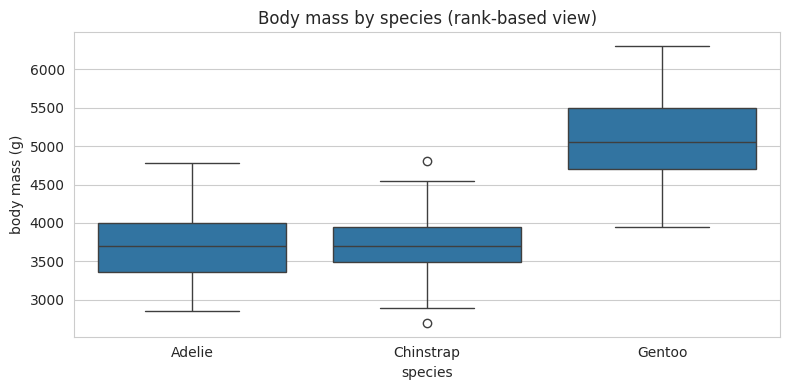

In [17]:
# [C19] [도식] 비모수가 보는 그림 — 분포 전체를 집단별로 (seaborn)
fig, ax = plt.subplots(figsize=(8, 4))                            # 그래프 하나를 그릴 도화지 준비
sns.boxplot(data=penguins, x="species", y="body_mass_g", ax=ax,   # 상자그림 — 중앙값·사분위·이상치를 한눈에
            order=["Adelie", "Chinstrap", "Gentoo"])
ax.set_title("Body mass by species (rank-based view)")
ax.set_ylabel("body mass (g)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

> **읽는 법(그림):** 상자그림은 *중앙값(가운데 선)*과 *퍼짐(상자)*, *이상치(점)*를 한눈에 보여줍니다. 비모수 검정은 바로 이 "분포의 위치"가 집단 간에 어긋나는지를 봅니다 — 평균 하나에 의존하지 않습니다.

> 📌 **다른 산업에서는?** 비모수 검정은 응답시간(IT), 소득·매출(금융·이커머스), 설문 리커트 척도(순위형), 소표본 임상시험처럼 *정규성을 장담 못 하는* 곳에서 광범위하게 쓰입니다.

## "순위로 비교한다"는 게 무슨 뜻일까

비모수 검정은 원래 값을 버리고 **전체를 한 줄로 세운 등수**만 씁니다. 작은 예로 직접 봅시다.

## 예제 · 순위(rank)는 이렇게 매겨진다

In [18]:
# [C20] 순위(rank)는 이렇게 매겨진다 — 두 집단을 합쳐 등수만 남긴다
A = [12, 15, 22]        # 집단 A
B = [18, 25, 30, 40]    # 집단 B
allv = np.array(A + B)
ranks = stats.rankdata(allv)        # 전체를 합쳐 등수 부여
print("값  :", allv.tolist())
print("순위:", ranks.tolist())
print(f"A의 순위합 = {ranks[:3].sum():.0f},  B의 순위합 = {ranks[3:].sum():.0f}")
print("→ Mann-Whitney U는 이 '순위합'으로 두 집단의 위치 차이를 잽니다. 값 40을 100만으로 바꿔도 순위는 그대로!")

값  : [12, 15, 22, 18, 25, 30, 40]
순위: [1.0, 2.0, 4.0, 3.0, 5.0, 6.0, 7.0]
A의 순위합 = 7,  B의 순위합 = 21
→ Mann-Whitney U는 이 '순위합'으로 두 집단의 위치 차이를 잽니다. 값 40을 100만으로 바꿔도 순위는 그대로!


> **읽는 법:** 값이 순위로 바뀌면, 극단값(40을 100만으로 바꿔도 등수는 7위 그대로)이 결과를 흔들지 못합니다. 이게 비모수가 이상치에 강한 이유입니다. 대신 "평균이 몇 만큼 다르다" 같은 *크기* 정보는 버립니다 — 그래서 효과 크기를 따로 봅니다.

## 예제 · 비모수 효과 크기 (rank-biserial)

In [19]:
# [C21] 비모수 효과 크기 — rank-biserial correlation (Mann-Whitney용)
m = tips.loc[tips["sex"] == "Male",   "total_bill"]
f = tips.loc[tips["sex"] == "Female", "total_bill"]
U, p = stats.mannwhitneyu(m, f, alternative="two-sided")          # Mann-Whitney U — 2표본 t-test의 비모수 짝꿍(순위 비교)
rank_biserial = 1 - 2 * U / (len(m) * len(f))   # -1~1, 0이면 차이 없음
print(f"Mann-Whitney U = {U:.0f}, p = {p:.4f}")
print(f"rank-biserial 효과 크기 = {abs(rank_biserial):.3f}  (0 작음 ~ 1 큼)")
print("→ 유의성(p)과 함께 '얼마나 다른가'(효과 크기)를 보고하는 습관은 모수·비모수 공통입니다.")

Mann-Whitney U = 8046, p = 0.0214
rank-biserial 효과 크기 = 0.178  (0 작음 ~ 1 큼)
→ 유의성(p)과 함께 '얼마나 다른가'(효과 크기)를 보고하는 습관은 모수·비모수 공통입니다.


> 💡 **비모수의 대가:** 데이터가 *정말 정규분포*라면, 같은 표본에서 비모수 검정은 t-test보다 검정력이 약간 낮습니다(정보를 일부 버리니까요). 그래서 "정규성이 그럴듯하면 모수, 의심스러우면 비모수"가 균형점입니다. 둘 다 돌려 결론이 같으면 더 안심할 수 있습니다.

## ⌨️ 백문이 불여일타! (3) — 종별 부리 길이 Kruskal-Wallis

```
[문제]
1) penguins에서 부리 길이(bill_length_mm)가 종별로 다른지 Kruskal-Wallis로 검정해보세요.
2) 종별 박스플롯을 그려 분포 차이를 눈으로 확인해보세요.
```

[Kruskal-Wallis 검정]
H-통계량 = 236.90
p-value = 3.61e-52


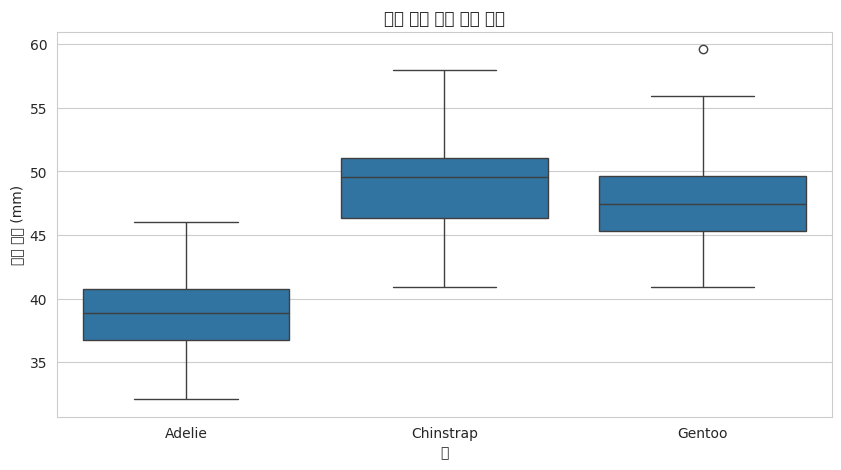

In [28]:
# [C22] ⌨️ 백문이 불여일타! (3) — 종별 부리 길이 Kruskal-Wallis 검정

# 1. 종별 부리 길이 Kruskal-Wallis 검정
bill = penguins.dropna(subset=["bill_length_mm", "species"])
adelie = bill.loc[bill["species"] == "Adelie", "bill_length_mm"]
chinstrap = bill.loc[bill["species"] == "Chinstrap", "bill_length_mm"]
gentoo = bill.loc[bill["species"] == "Gentoo", "bill_length_mm"]

h_stat, p_value = stats.kruskal(adelie, chinstrap, gentoo)
print("[Kruskal-Wallis 검정]")
print(f"H-통계량 = {h_stat:.2f}")
print(f"p-value = {p_value:.2e}")

# 2. 종별 부리 길이 박스플롯
sns.boxplot(x="species", y="bill_length_mm", data=bill)
plt.title("펭귄 종별 부리 길이 분포")
plt.xlabel("종")
plt.ylabel("부리 길이 (mm)")
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- [C18]에서 `body_mass_g`로 수행한 Kruskal-Wallis 코드를 본떠 컬럼명만 `bill_length_mm`로 바꾸면 됩니다.
- 종별 값 목록은 `penguins.groupby("species")`로 만들고, `stats.kruskal(*그룹_리스트)`처럼 풀어서 넣습니다.
- 박스플롯은 `sns.boxplot`에 `x="species"`, `y="bill_length_mm"`를 지정하면 됩니다.

</details>

## 🚦 짚고 넘어가기 — Part 6 비모수 3종

1. 비모수 검정이 "값" 대신 사용하는 것은 무엇이고, 그 장점은 무엇인가요?
2. Mann-Whitney U·Wilcoxon·Kruskal-Wallis는 각각 어떤 모수 검정의 대안인가요?
3. 비모수 검정의 단점(대가)은 무엇인가요?

> 💡 **다음 Part 예고:** 이제 "언제 모수, 언제 비모수인가"를 정리하고, 범주형의 꽃인 **A/B 테스트**를 카이제곱으로 분석해봅니다.

# Part 7. 모수 vs 비모수, 그리고 A/B 테스트

도구를 다 모았으니, 이제 *고르는 기준*을 정리하고 실무의 대표 사례인 A/B 테스트에 적용해봅시다.

> ❓ **이 파트에서 답할 질문:** 모수와 비모수는 무엇을 기준으로 고르고, 클릭·구매 같은 A/B 결과는 어떤 검정으로 분석할까요?

## 모수 vs 비모수 — 선택 기준

| 기준 | 모수 검정 (t-test·ANOVA) | 비모수 검정 (순위) |
|------|--------------------------|--------------------|
| 가정 | 정규성·등분산 필요 | 거의 없음 (분포 자유) |
| 사용 대상 | 값(평균) | 순위(중앙값 경향) |
| 표본 크기 | 클수록 안정 | 소표본·이상치에 강함 |
| 검정력 | 가정 맞으면 더 높음 | 약간 낮을 수 있음 |
| 언제 | 정규성 OK, 큰 표본 | 비정규·이상치·순위형·소표본 |

> 💡 **실무 원칙:** 표본이 크고 정규성이 그럴듯하면 모수가 효율적입니다. 그러나 *의심스러우면 비모수가 안전*합니다 — 잘못된 가정으로 얻은 작은 p보다, 가정이 적은 견고한 결론이 낫습니다.

한 가지 덧붙이면, '모수냐 비모수냐'는 흑백 선택이 아닙니다. 실무에서는 **둘 다 돌려보고 결론이 일치하는지 확인**하는 경우가 많습니다. 두 검정이 같은 답을 주면(대개 그렇습니다) 가정 위반을 크게 걱정하지 않아도 된다는 안심을 얻고, 서로 다른 답을 주면 그 자체가 "데이터에 뭔가 특별한 구조(강한 이상치, 심한 비대칭)가 있다"는 신호가 됩니다. 그때는 분포를 다시 그려보고 *왜* 갈렸는지 파고들면 됩니다.

또 자주 받는 질문 — "표본이 크면 무조건 모수 검정을 써도 되나요?" 중심극한정리 덕분에 표본이 충분히 크면 표본평균의 분포가 정규에 가까워져서, 원자료가 다소 비정규여도 t-test·ANOVA가 꽤 잘 작동합니다. 그래서 수천 건 이상의 큰 데이터라면 모수 검정으로 가는 경우가 많습니다. 다만 *이상치가 결과를 좌우할 만큼 극단적*이거나 애초에 *순위·서열 자료*(리커트 척도 등)라면, 표본이 커도 비모수가 더 적절합니다.

결국 핵심은 반복됩니다 — 검정은 답을 찍어주는 자판기가 아니라 *데이터와 대화하는 도구*입니다. 그리고 어떤 검정을 쓰든 결과는 늘 **유의성(p)과 효과 크기를 함께** 보고한다는 원칙만큼은 모수·비모수를 가리지 않습니다.

## A/B 테스트를 카이제곱으로

A/B 테스트의 결과가 "클릭함/안 함", "구매함/안 함" 같은 **범주형(전환 여부)**이면, 두 그룹의 전환율 차이가 유의한지를 **카이제곱 독립성 검정**(그룹 × 전환)으로 따집니다.

> 아래에서는 **실제 무작위 배정 현장실험 데이터**(`ResumeNames`)를 씁니다. 같은 이력서에 이름만 무작위로 바꿔 보내고 면접 연락 여부를 기록했으므로, 구조가 A/B 테스트와 정확히 같습니다 — *그룹 2개 × 결과(예/아니오)*.

## A/B 테스트 — 통계가 비즈니스를 만나는 곳

A/B 테스트는 오늘 배운 카이제곱이 현업에서 가장 자주 쓰이는 무대입니다. 웹사이트 버튼 색을 바꿔보고(A=기존, B=신규) 어느 쪽 클릭률이 높은지, 이메일 제목 두 개 중 어느 쪽 개봉률이 높은지 — 이런 질문은 전부 "그룹(A/B) × 결과(전환/비전환)"라는 2×2 분할표로 정리됩니다. 그리고 "두 그룹의 전환율 차이가 우연인가, 진짜인가"를 카이제곱이 판정합니다.

여기서 앞서 배운 교훈이 그대로 살아납니다. **유의성(p)만으로 의사결정을 하면 안 됩니다.** 전환율이 11.0%에서 11.2%로 '통계적으로 유의하게' 올랐어도, 그 0.2%p를 얻으려 드는 개발·운영 비용이 더 크면 채택할 이유가 없습니다. 그래서 실무에서는 *효과 크기(전환율 상승폭)*와 *비즈니스 비용·편익*을 함께 봅니다.

또 하나, 실험을 *시작하기 전에* 따져야 할 게 있습니다 — "이 정도 차이를 잡으려면 표본이 얼마나 필요한가(검정력)?"입니다. 표본이 부족하면 진짜 차이가 있어도 못 잡고, 'peeking'(데이터를 엿보다 유의해지면 멈추기)은 거짓 양성을 부풉니다. 통계는 실험이 *끝난 뒤*가 아니라 *설계할 때*부터 개입해야 한다는 뜻입니다. 아래에서 실제 A/B 데이터를 카이제곱으로 분석해봅니다.

## 예제 · A/B형 카이제곱 — 그룹 × 연락 여부

In [20]:
# [C23] A/B 테스트형 분석 — 그룹 × 결과(연락 여부) 2x2 분할표, 카이제곱 검정
#   실데이터: ResumeNames (동일 이력서에 이름만 무작위 배정한 현장실험)
ab = pd.crosstab(resume["ethnicity"], resume["call"])          # 행=그룹, 열=연락 여부
ab = ab[["yes", "no"]]                                          # 보기 좋게 열 순서 정리
ab.index = ["그룹 A (afam형 이름)", "그룹 B (cauc형 이름)"]
ab.columns = ["연락옴", "연락없음"]
print("A/B 분할표 (실제 현장실험 결과):")
print(ab)

chi2_ab, p_ab, dof_ab, exp_ab = stats.chi2_contingency(ab)        # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
rate_a = ab.iloc[0, 0] / ab.iloc[0].sum()
rate_b = ab.iloc[1, 0] / ab.iloc[1].sum()

# 효과 크기 두 가지: Cramér's V(연관의 세기)와 오즈비(OR)
V_ab = np.sqrt(chi2_ab / (ab.values.sum() * (min(ab.shape) - 1)))
odds_ab = (ab.iloc[1, 0] * ab.iloc[0, 1]) / (ab.iloc[1, 1] * ab.iloc[0, 0])

print(f"\n연락률: A = {rate_a:.2%},  B = {rate_b:.2%}   (절대 차이 {rate_b - rate_a:+.2%}p)")
print(f"카이제곱: chi2 = {chi2_ab:.2f}, df = {dof_ab}, p = {p_ab:.2e}")
print(f"효과 크기: Cramér's V = {V_ab:.3f}   오즈비 OR = {odds_ab:.2f}")
print(f"각 칸 최소 기대빈도 = {exp_ab.min():.1f}  (5 이상이면 카이제곱 근사 OK)")

A/B 분할표 (실제 현장실험 결과):
                 연락옴  연락없음
그룹 A (afam형 이름)  157  2278
그룹 B (cauc형 이름)  235  2200

연락률: A = 6.45%,  B = 9.65%   (절대 차이 +3.20%p)
카이제곱: chi2 = 16.45, df = 1, p = 5.00e-05
효과 크기: Cramér's V = 0.058   오즈비 OR = 1.55
각 칸 최소 기대빈도 = 196.0  (5 이상이면 카이제곱 근사 OK)


> **읽는 법:** p가 0.001보다 작아 "그룹과 연락 여부는 독립"이라는 가정을 기각합니다 — 두 그룹의 연락률 차이(약 3%p)를 우연으로 보기 어렵다는 뜻입니다.
>
> **그런데 효과 크기를 보세요.** Cramér's V가 0.06 정도로, 앞의 기준표(0.1 작음 / 0.3 중간 / 0.5 큼)로는 "매우 작음"입니다. 반면 오즈비는 1.5를 넘습니다. 같은 결과가 왜 이렇게 달라 보일까요?
>
> - **V(0.06)** 는 "이 표의 전체 변동 중 그룹이 설명하는 몫"에 가까운 지표입니다. 연락 자체가 드물어(8%) 대부분의 칸이 '연락없음'이라, 어떤 분할이든 V가 커지기 어렵습니다.
> - **OR(1.55)·상대비(1.5배)** 는 "연락을 받을 오즈가 한쪽에서 1.5배"라는 뜻입니다. *당사자에게는 결정적인 크기*입니다.
>
> 💡 **그래서 오늘의 교훈이 하나 더 늘었습니다.** 효과 크기 기준표(V·d)는 *출발점*일 뿐이고, **최종 판단은 도메인의 의미와 비용·편익**으로 합니다(D013에서 "맥락이 기준보다 먼저"라고 했던 그 얘기입니다). 이 사례에서는 V가 작아도 결코 "사소한" 결과가 아닙니다.
>
> ⚠️ 보고할 때는 **① 각 그룹의 실제 비율 ② 절대 차이(%p) ③ 상대비·오즈비 ④ 유의성**을 함께 적으세요. 상대비만 강조하면 과장되고, V만 강조하면 과소평가됩니다.

## 그림으로 · 두 그룹의 연락률과 95% 신뢰구간

          group   rate     lo     hi    n
그룹 A (afam형 이름) 0.0645 0.0554 0.0749 2435
그룹 B (cauc형 이름) 0.0965 0.0854 0.1089 2435


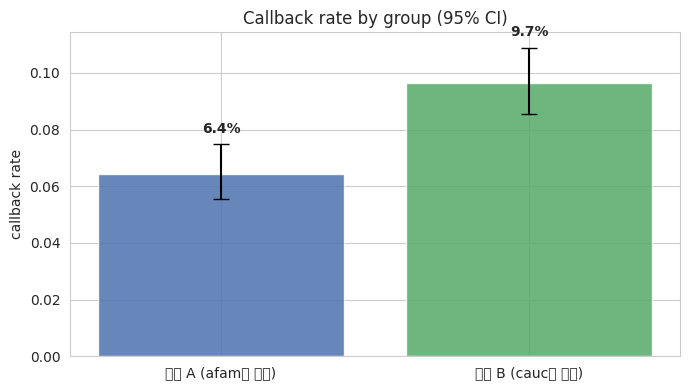

In [21]:
# [C24] [도식] 두 그룹의 연락률 비교 + 95% 신뢰구간
from statsmodels.stats.proportion import proportion_confint

rows = []
for label in ab.index:
    succ, n = int(ab.loc[label, "연락옴"]), int(ab.loc[label].sum())
    lo, hi = proportion_confint(succ, n, method="wilson")     # 비율의 95% 신뢰구간
    rows.append({"group": label, "rate": succ / n, "lo": lo, "hi": hi, "n": n})
res = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.bar(res["group"], res["rate"], color=["#4C72B0", "#55A868"], alpha=0.85)
ax.errorbar(res["group"], res["rate"],                            # 오차막대(신뢰구간) 표시
            yerr=[res["rate"] - res["lo"], res["hi"] - res["rate"]],
            fmt="none", ecolor="black", capsize=6)
for i, r in res.iterrows():
    ax.text(i, r["hi"] + 0.004, f"{r['rate']:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("callback rate"); ax.set_title("Callback rate by group (95% CI)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(res.round(4).to_string(index=False))

> **읽는 법(그림):** 두 그룹의 연락률과 95% 신뢰구간입니다. 두 구간이 **서로 겹치지 않아** 차이가 뚜렷하다는 시각 신호를 줍니다(카이제곱 p가 작았던 것과 같은 이야기). 막대 높이 차이가 "눈에 띄는가"와 "통계적으로 유의한가"는 다른 질문이고, 그 판정을 카이제곱과 신뢰구간이 함께 해줍니다.
>
> 💡 오차선(신뢰구간)이 없는 막대그래프는 *불확실성을 숨긴 그림*입니다. 비율을 보고할 때는 구간을 꼭 함께 그리세요.

> 📌 **다른 산업에서는?** 그룹 × 범주 결과의 카이제곱은 이메일 제목 A/B(개봉률), UI 버튼 색(클릭률), 약물 vs 위약(회복 여부), 공정 변경(불량 여부) 비교에 똑같이 쓰입니다.

## A/B를 설계할 때 — 표본은 얼마나 필요할까

A/B에서 "차이가 없다"는 결과가 *정말 차이가 없어서*인지, *표본이 작아 못 잡아서*인지 구분하려면 **검정력**을 생각해야 합니다. 잡고 싶은 차이가 작을수록 더 많은 표본이 필요합니다.

방금 본 실험도 그룹당 2,435건이었습니다. 만약 각 그룹이 200건이었다면 같은 3%p 차이를 잡아낼 수 있었을까요? 아래에서 기준 연락률 8%를 출발점으로 삼아 감을 잡아봅시다.

In [22]:
# [C25] 전환율 차이별로 '유의'해지는 데 필요한 대략의 표본 (감 잡기용 모의실험)
# 기준 비율은 위 실험에서 관측된 전체 연락률(약 8%)을 씁니다.
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
base = float((resume["call"] == "yes").mean())
print(f"기준 비율(관측 전체 연락률) = {base:.3f}\n")

for lift in [0.01, 0.02, 0.03, 0.05]:
    found = None
    for n in [200, 500, 1000, 2500, 5000, 20000]:
        hits = 0
        for _ in range(120):
            a = np.random.binomial(n, base)                       # 이항 난수 — n번 시도 중 성공 횟수
            b = np.random.binomial(n, base + lift)                # 이항 난수 — n번 시도 중 성공 횟수
            if stats.chi2_contingency([[a, n - a], [b, n - b]])[1] < 0.05:  # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
                hits += 1
        if hits / 120 >= 0.8:            # 약 80% 검정력
            found = n
            break
    msg = f"그룹당 약 {found:,}명 이상 필요" if found else "20,000명으로도 80% 검정력 미달"
    print(f"  +{lift*100:.0f}%p 차이를 80% 확률로 잡으려면 : {msg}")

기준 비율(관측 전체 연락률) = 0.080

  +1%p 차이를 80% 확률로 잡으려면 : 그룹당 약 20,000명 이상 필요
  +2%p 차이를 80% 확률로 잡으려면 : 그룹당 약 5,000명 이상 필요
  +3%p 차이를 80% 확률로 잡으려면 : 그룹당 약 2,500명 이상 필요
  +5%p 차이를 80% 확률로 잡으려면 : 그룹당 약 1,000명 이상 필요


> **읽는 법:** 잡고 싶은 차이가 *작을수록* 필요한 표본이 급격히 커집니다. "유의하지 않음"이 "효과 없음"이 아니라 "표본 부족"일 수 있다는 앞서 배운 교훈이 A/B 설계에서 그대로 살아납니다.

> ➕ **더 알고 싶다면:** 실무에선 실험 *전에* 목표 효과 크기·검정력(보통 0.8)·유의수준으로 **필요 표본 수를 미리 계산**(Power Analysis)하고 기간을 정합니다. 데이터를 보다가 유의해지는 순간 멈추는 'peeking'은 1종 오류를 부풀리므로 피합니다.

## ⌨️ 백문이 불여일타! (4) — quality × call 카이제곱

```
[문제]
같은 실험에서 무작위로 배정된 또 다른 요인이 있습니다 — 이력서의 품질(quality: high / low).
1) resume에서 quality × call 분할표를 만들고 카이제곱 검정을 수행해보세요.
2) 두 품질 그룹의 연락률과 p값을 출력하고, 앞의 ethnicity 결과와 결론이 어떻게 다른지 적어보세요.
3) (생각해보기) "유의하지 않다"가 "효과가 없다"는 뜻인지, 무엇을 더 확인해야 할지 주석으로 정리해보세요.
```

In [29]:
# [C26] ⌨️ 백문이 불여일타! (4) — quality × call 카이제곱 검정

# 1. quality × call 분할표와 카이제곱 검정
ct_quality = pd.crosstab(resume["quality"], resume["call"])
chi2, p, dof, expected = stats.chi2_contingency(ct_quality)

print("[quality × call 분할표]")
print(ct_quality)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")

# 2. 품질 그룹별 연락률
call_rates = resume.groupby("quality")["call"].apply(lambda s: (s == "yes").mean())
print("\n[품질 그룹별 연락률]")
print(call_rates.apply(lambda x: f"{x:.2%}"))

# 결론
if p < 0.05:
    print("\n결론: 이력서 품질과 연락 여부 사이에 통계적으로 유의한 연관성이 있습니다.")
else:
    print("\n결론: 이력서 품질과 연락 여부 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.")
    print("앞의 ethnicity 결과와 달리, quality에서는 p값이 0.05보다 커 뚜렷한 효과가 나타나지 않았습니다.")

# 유의하지 않다가 곧 효과가 없다는 뜻은 아니며,cramer's v 추가 확인이 필요함.

[quality × call 분할표]
call       no  yes
quality           
high     2232  214
low      2246  178

chi2 = 3.06, df = 1, p = 0.0801

[품질 그룹별 연락률]
quality
high    8.75%
low     7.34%
Name: call, dtype: object

결론: 이력서 품질과 연락 여부 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.
앞의 ethnicity 결과와 달리, quality에서는 p값이 0.05보다 커 뚜렷한 효과가 나타나지 않았습니다.


<details>
<summary>(클릭) 💡 힌트</summary>

- 분할표는 `pd.crosstab(resume["quality"], resume["call"])`로 만듭니다 — [C4]·[C23]에서 쓴 그 방법입니다.
- 검정은 `stats.chi2_contingency(분할표)`로 동일합니다. 각 그룹의 연락률은 `resume.groupby("quality")["call"].apply(lambda s: (s == "yes").mean())`로 구할 수 있습니다.
- p를 0.05와 비교해 결론을 적고, 앞의 `ethnicity` 결과(p가 매우 작았음)와 나란히 비교해보세요.

</details>

## 🚦 짚고 넘어가기 — Part 7 모수 vs 비모수와 A/B

1. 모수와 비모수를 가르는 핵심 기준 두 가지는 무엇인가요?
2. "클릭함/안 함" 같은 A/B 결과는 어떤 검정으로 분석하나요?
3. A/B에서 p가 유의해도 추가로 봐야 하는 것은 무엇인가요?

> 💡 **다음 Part 예고:** 배운 도구를 모아, 여러 데이터에 *직접 검정을 골라* 수행하고 보고서로 정리하는 종합 실습으로 마무리합니다.

## 잠깐 — '검정을 고른다'는 것의 진짜 의미

종합 실습에 들어가기 전에, 오늘의 가장 중요한 태도를 한 번 짚고 가겠습니다. 많은 입문자가 통계 검정을 *"외워서 갖다 쓰는 공식"*으로 생각합니다. "두 집단이면 t-test, 세 집단이면 ANOVA" 식으로요. 하지만 실무에서 진짜 실력은 **검정을 고르는 판단**에서 갈립니다.

검정 선택은 사실 *데이터를 진단하는 일*입니다. 의사가 증상을 보고 검사를 정하듯, 여러분은 데이터를 보고 묻습니다 — "비교하려는 게 숫자인가 범주인가? 숫자라면 분포가 정규에 가까운가, 일그러졌는가? 두 집단인가 세 집단 이상인가? 짝지어진 측정인가 독립된 집단인가? 표본은 충분한가?" 이 질문들의 답이 모이면, 어울리는 검정은 거의 자동으로 정해집니다. Part 3의 *검정 선택 지도*가 바로 이 진단 흐름을 한 장에 담은 것이었습니다.

그래서 아래 종합 실습에서 여러분이 보여줄 핵심 역량은 '검정을 돌리는 것'이 아니라 **'왜 그 검정을 골랐는지 설명하는 것'**입니다. 보고서 양식에 *검정 선택 근거* 칸을 일부러 크게 둔 이유입니다. 결과의 p값보다, 그 p값에 이르기까지의 *판단 과정*이 여러분을 '도구를 쓰는 사람'에서 '도구를 고르는 사람'으로 끌어올립니다.

# 🧪 종합 실습 — 검정을 선택·수행·보고하기

실제 데이터 세 종류에 *적절한 검정을 스스로 골라* 적용하고, 그 결과를 **의사결정 보고서**로 정리합니다. 오늘의 핵심 역량 — "데이터 특성에 맞는 선택" — 을 발휘할 시간입니다.

```text
[1] titanic 등급 × 생존 (범주형)   → 카이제곱 독립성
[2] china_smoking 흡연 × 폐암       → 카이제곱 (고전 분할표)
[3] titanic 요금(fare) 등급별 차이  → 비정규 → Kruskal-Wallis
```

## 종합 [1] · 등급 × 생존 (카이제곱 독립성)

In [23]:
# [C27] [1] titanic — 객실 등급 × 생존 (카이제곱 독립성)
ct = pd.crosstab(titanic["class"], titanic["survived"])           # 분할표(교차표) — 두 범주의 조합별 개수를 셈
chi2, p, dof, _ = stats.chi2_contingency(ct)                      # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
print("[1] 등급 × 생존")
print(ct)
print(f"   chi2 = {chi2:.1f}, df = {dof}, p = {p:.2e}  → 등급과 생존은 관련 있음\n")

[1] 등급 × 생존
survived    0    1
class             
First      80  136
Second     97   87
Third     372  119
   chi2 = 102.9, df = 2, p = 4.55e-23  → 등급과 생존은 관련 있음



## 종합 [2] · 흡연 × 폐암 (카이제곱 + 오즈비)

In [24]:
# [C28] [2] china_smoking — 흡연 × 폐암 (지역별 카운트를 합산해 2x2 구성)
cs = sm.datasets.china_smoking.load_pandas().data
table = np.array([[cs["smoking_yes_cancer_yes"].sum(), cs["smoking_yes_cancer_no"].sum()],
                  [cs["smoking_no_cancer_yes"].sum(),  cs["smoking_no_cancer_no"].sum()]])
ct_smoke = pd.DataFrame(table, index=["흡연", "비흡연"], columns=["폐암", "정상"])
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(ct_smoke)          # 카이제곱 독립성 검정 → chi2, p, 자유도, 기대빈도
# 오즈비(odds ratio)로 연관 강도까지
odds = (table[0,0]*table[1,1]) / (table[0,1]*table[1,0])
print("[2] 흡연 × 폐암 (전 지역 합산)")
print(ct_smoke)
print(f"   chi2 = {chi2_s:.1f}, df = {dof_s}, p = {p_s:.2e},  오즈비 = {odds:.2f}")
print("   → 흡연과 폐암은 강하게 연관(오즈비가 1보다 훨씬 큼)\n")

[2] 흡연 × 폐암 (전 지역 합산)
       폐암    정상
흡연   2930  2359
비흡연  1151  1979
   chi2 = 272.3, df = 1, p = 3.50e-61,  오즈비 = 2.14
   → 흡연과 폐암은 강하게 연관(오즈비가 1보다 훨씬 큼)



> **읽는 법:** 흡연 × 폐암 분할표에서 카이제곱 p는 사실상 0이고, **오즈비**가 1을 크게 웃돕니다 — 흡연군의 폐암 오즈가 비흡연군의 몇 배라는 뜻입니다. 카이제곱이 "관련 있다"를, 오즈비가 "얼마나 강한가(효과 크기)"를 말해줍니다. (단, 관찰 데이터이므로 *인과*가 아니라 *연관*입니다 — 이후 배울 주제!)

## 종합 [3] · 등급별 요금 (Kruskal-Wallis)

In [25]:
# [C29] [3] titanic — 요금(fare)은 우편향 → 등급별 비교는 Kruskal-Wallis
print("[3] 요금(fare) 정규성 점검:", f"Shapiro p = {stats.shapiro(titanic['fare'].dropna()).pvalue:.2e} (비정규)")  # 정규성 검정 — H0: 정규분포를 따른다
fare_groups = [g["fare"].dropna().values for _, g in titanic.groupby("class")]  # 결측(NaN) 제거
H, p_h = stats.kruskal(*fare_groups)                              # Kruskal-Wallis — ANOVA의 비모수 짝꿍
print(f"   Kruskal-Wallis: H = {H:.1f}, p = {p_h:.2e}  → 등급별 요금 분포가 다름")
for name, g in titanic.groupby("class"):                          # 집단별로 묶어서 계산
    print(f"   {name:7s} 요금 중앙값 {g['fare'].median():.1f}")

[3] 요금(fare) 정규성 점검: Shapiro p = 1.08e-43 (비정규)
   Kruskal-Wallis: H = 438.0, p = 7.59e-96  → 등급별 요금 분포가 다름
   First   요금 중앙값 60.3
   Second  요금 중앙값 14.2
   Third   요금 중앙값 8.1


## 📋 검정 선택·결과 보고서 (의사결정 보고서)

위 결과를 아래 양식으로 정리하세요. 다음 정기 보고에 그대로 들어갈 산출물입니다.

```markdown
# 검정 선택·결과 보고서

## 1. 분석 질문과 데이터
- (예) 객실 등급/흡연 여부가 생존/폐암과 관련 있는가? 등급별 요금 분포는 다른가?
  무작위 배정된 두 그룹의 연락률이 다른가?

## 2. 검정 선택 근거  ← 오늘의 핵심
| 질문 | 데이터 특성 | 선택한 검정 | 이유 |
| --- | --- | --- | --- |
| 등급 × 생존 | 둘 다 범주형 | 카이제곱 독립성 | 빈도 비교 |
| 흡연 × 폐암 | 2×2 범주형 | 카이제곱 + 오즈비 | 연관·강도 |
| 그룹 × 연락 | 2×2 범주형(무작위 배정) | 카이제곱 + V·OR | A/B 구조 |
| 등급별 요금 | 연속형·우편향 | Kruskal-Wallis | 정규성 위배 |
| 같은 기업 87/88 불량률 | 짝지어진 연속형·비정규 | Wilcoxon 부호순위 | 대응 + 정규성 위배 |

## 3. 결과 요약
| 분석 | 통계량 | 효과 크기 | p | 결론 |
| --- | --- | --- | --- | --- |
| 등급×생존 | chi2=__ | V=__ | __ | 관련 있음 |
| 흡연×폐암 | chi2=__ | OR=__ | __ | 강한 연관 |
| 그룹×연락 | chi2=__ | V=__, OR=__ | __ | 연락률 차이 있음 |
| 등급별 요금 | H=__ | — | __ | 분포 다름 |
| 87/88 불량률 | W=__ | — | __ | 감소 |

## 4. 의사결정 제안과 한계
- (행동) ...
- (한계) 관찰 데이터의 연관은 인과가 아님. 단, 그룹×연락은 *무작위 배정*이라 인과 해석의
  여지가 큼 → 그 차이가 왜 중요한지는 D016(A/B·인과추론)에서 다룸.
```

> 💡 빈칸(`__`)은 위 출력으로 채우고, **"왜 그 검정을 골랐는지"**(2번)를 한 줄씩 적으면 훌륭한 보고서가 됩니다.

## ⌨️ 백문이 불여일타! (5) — 성별 × 종 카이제곱

```
[문제]
1) penguins에서 성별(sex) × 종(species)이 관련 있는지(=종마다 성비가 다른지) 카이제곱으로 검정해보세요.
2) 결과를 위 보고서 양식의 한 줄로 적어보세요.
```

In [30]:
# [C30] ⌨️ 백문이 불여일타! (5) — 성별 × 종 카이제곱 검정과 보고서 한 줄

# 성별 × 종 분할표
ct_sex_species = pd.crosstab(penguins["sex"], penguins["species"])

# 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(ct_sex_species)

print("[성별 × 종 분할표]")
print(ct_sex_species)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")

if p < 0.05:
    print("결론: 성별과 종 사이에 통계적으로 유의한 연관성이 있습니다.")
else:
    print("결론: 성별과 종 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.")

# 카이제곱 검정 결과, 성별과 종은 (χ²(2) = 0.05, p = 0.9760)으로 표본의 성비 균형에 가까움.
# p가 큰 경우에는 독립으로 볼 수 있음.
# cramer's V 추가 확인이 필요함.

[성별 × 종 분할표]
species  Adelie  Chinstrap  Gentoo
sex                               
Female       73         34      58
Male         73         34      61

chi2 = 0.05, df = 2, p = 0.9760
결론: 성별과 종 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.


<details>
<summary>(클릭) 💡 힌트</summary>

- 분할표는 `pd.crosstab(penguins["species"], penguins["sex"])`로 만듭니다.
- 절차는 [C4]의 독립성 검정과 같습니다 — 분할표를 `stats.chi2_contingency`에 넣으면 됩니다.
- 보고서 한 줄에는 검정 이름·통계량·자유도·`p`·결론이 들어갑니다. 이번에는 `p`가 큰 경우의 해석("독립으로 볼 수 있음")도 연습해보세요.

</details>

## 결과를 제대로 보고하는 법 — 표준 표기와 흔한 실수

오늘 배운 검정도 앞서처럼 **표준 형식**으로 보고합니다(학계·실무 공통).

| 검정 | 표준 보고 형식 (예) |
|------|---------------------|
| 카이제곱 독립성 | 성별과 생존은 관련이 있었다, `χ²(1, N=891) = 260.7, p < .001, Cramér's V = 0.54`(강함) |
| 카이제곱 (A/B형) | 두 그룹의 연락률이 달랐다(9.7% vs 6.4%), `χ²(1, N=4870) = 16.4, p < .001, OR = 1.55, V = 0.06` |
| Mann-Whitney U | 두 집단의 결제액 분포가 달랐다, `U = 8046, p = .021`(rank-biserial = 0.18) |
| Wilcoxon 부호순위 | 같은 기업의 불량률이 감소했다, `W = 329, p = .003` (n = 54) |
| Kruskal-Wallis | 종에 따라 체중 분포가 달랐다, `H(2) = 212.1, p < .001` |

*위 숫자는 이 노트북 셀들의 실제 출력에서 가져온 값입니다. 여러분의 보고서에는 **반드시 자기 분석 출력의 숫자**를 넣으세요.*

> 📌 **흔한 실수 5가지 (제출 전 체크):**
> 1. 카이제곱 결과를 **인과로 해석** → 관찰 데이터의 연관은 인과가 아닙니다(흡연×폐암도 본문에선 "연관"까지)
> 2. **기대빈도 5 미만**인 칸이 많은데 그냥 카이제곱 → Fisher 정확검정을 쓰세요
> 3. **효과 크기(Cramér's V·오즈비)를 빼먹음** → 큰 표본에선 사소한 연관도 유의해집니다
> 4. 비정규인데 **t-test를 고집** → 비모수(순위) 검정을 고려하세요
> 5. 비모수 결과를 "평균이 다르다"로 서술 → 비모수는 *분포의 위치(중앙값 경향)*를 비교합니다

> 💡 **한 문장 원칙:** *데이터 타입을 먼저 진단하고(범주/연속·정규/비정규), 검정을 고른 이유를 적고, 유의성과 효과 크기를 세트로 보고하라.*

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다.

## 개념 퀴즈

1. 두 범주형 변수의 연관성을 검정할 때 쓰는 것은? ( ① 대응표본 t-test  ② 카이제곱 독립성 검정  ③ Kruskal-Wallis )
2. 카이제곱 검정에서 각 칸의 **기대빈도**가 너무 작으면(예: 5 미만) 권장되는 대안은?
3. 정규성이 깨진 두 *독립* 집단을 비교할 때 쓰는 비모수 검정의 이름은?
4. 베이즈 정리에서, 정보를 알기 *전*의 확률을 ___확률, *후*의 확률을 ___확률이라 부릅니다.

## 코드 퀴즈

tips 데이터에서 **흡연 여부(smoker) × 시간대(time)**가 관련 있는지 카이제곱으로 검정하세요.

In [31]:
# [C31] 코드 퀴즈 — smoker × time 카이제곱 독립성 검정

# 흡연 여부 × 시간대 분할표
ct_smoker_time = pd.crosstab(tips["smoker"], tips["time"])

# 카이제곱 독립성 검정
chi2, p, dof, expected = stats.chi2_contingency(ct_smoker_time)

print("[흡연 여부 × 시간대 분할표]")
print(ct_smoker_time)
print(f"\nchi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")

if p < 0.05:
    print("결론: 흡연 여부와 시간대 사이에 통계적으로 유의한 연관성이 있습니다.")
else:
    print("결론: 흡연 여부와 시간대 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.")

[흡연 여부 × 시간대 분할표]
time    Lunch  Dinner
smoker               
Yes        23      70
No         45     106

chi2 = 0.51, df = 1, p = 0.4771
결론: 흡연 여부와 시간대 사이에 통계적으로 유의한 연관성을 확인하지 못했습니다.


## 오늘, 무엇이 바뀌었나 — 공식에서 판단으로

정리로 넘어가기 전에 잠시 멈춰, 오늘 여러분 안에서 일어난 변화를 짚어보겠습니다. 노트북을 시작할 때 우리에겐 't-test와 ANOVA'라는 망치 두 개가 있었습니다. 망치를 들면 모든 게 못으로 보입니다 — 어떤 데이터든 평균을 비교하려 들게 됩니다.

오늘 우리는 연장통을 넓혔습니다. 범주형에는 카이제곱을, 일그러진 분포에는 비모수를, '이미 일어난 일'의 확률에는 베이즈를 꺼낼 수 있게 됐습니다. 하지만 더 중요한 변화는 연장이 늘어난 게 아니라, **연장을 고르는 눈**이 생겼다는 점입니다. "이 데이터는 어떻게 생겼지? 그래서 무엇이 어울리지?"를 먼저 묻게 됐다면, 오늘의 진짜 목표를 이룬 겁니다.

이 'data-aware 사고'는 앞으로도 계속됩니다. 다음 시간부터는 '차이'를 넘어 '관계'와 '원인'으로 나아가는데(회귀·인과추론), 거기서도 똑같이 물을 거예요 — "내 데이터와 질문에 어떤 도구가 어울리는가?" 도구는 바뀌어도 사고의 틀은 같습니다. 그게 통계를 '암기 과목'이 아니라 '판단의 기술'로 만드는 길입니다.

마지막으로 자신에게 해볼 질문 하나를 남기겠습니다. 앞으로 어떤 데이터를 만나든, 분석을 시작하기 전에 스스로 물어보세요 — **"이 변수는 숫자인가 범주인가? 분포는 어떻게 생겼나? 내가 답하려는 질문은 '차이'인가 '관계'인가 '원인'인가?"** 이 세 질문에 답하는 습관만 들여도, 여러분은 이미 '도구에 끌려다니는 사람'이 아니라 '도구를 부리는 사람'입니다. 오늘 배운 카이제곱과 비모수는 그 연장통의 한 칸을 채웠을 뿐이고, 그 칸은 다음 시간부터 계속 늘어날 겁니다.

# 🎓 오늘의 정리

## 오늘 배운 것의 연결

```text
[Part 1] 평균을 못 쓰는 데이터
   ↓ 범주형이거나 / 정규성이 깨졌을 때
[Part 3] 검정 선택 지도 (데이터 타입 × 가정)
   ├─(범주형)→ [Part 4] 카이제곱 (독립성·적합도)
   │              ↓ 확률로 다시 보기
   │           [Part 5] 조건부확률·베이즈 정리
   └─(연속·비정규)→ [Part 6] 비모수 3종 (MWU·Wilcoxon·Kruskal)
                       ↓ 정리·적용
                    [Part 7] 모수 vs 비모수 + A/B 카이제곱
```

## 한 장 정리

| 도구 | 언제 | 무엇을 보나 |
|------|------|-------------|
| 카이제곱 독립성 | 두 범주형의 관련성 | 관측 vs 기대 빈도 |
| 카이제곱 적합도 | 한 범주형의 분포 | 기대 분포와의 어긋남 |
| 조건부확률·베이즈 | "이미 일어난 일"의 확률 | 정보로 갱신된 확률 |
| Mann-Whitney U | 2 독립집단(비정규) | 순위 합 |
| Wilcoxon | 대응(비정규) | 전후 차이의 순위 |
| Kruskal-Wallis | 3+ 집단(비정규) | 순위 기반 집단 차 |

## 진단 → 다음 분석 도구

| 진단 결과 | 자연스러운 다음 분석 |
|-----------|---------------------|
| 두 변수의 *관계의 방향·세기*가 궁금하다 | 상관·회귀 |
| 여러 변수로 한 값을 *예측·설명*하고 싶다 | 다중 회귀 |
| 관찰된 연관이 *진짜 원인*인지 알고 싶다 | 인과 추론·A/B 실험 |

> 💡 **다음 시간 예고:** 오늘은 "차이가 있나"를 따졌습니다. 다음은 **관계** — 두 변수가 어떻게 함께 움직이는지(상관), 그리고 여러 변수로 결과를 설명하는 **회귀분석**으로 넘어갑니다. 오늘 본 "연관 ≠ 인과"가 그 출발점입니다.

# 📝 오늘의 과제

오늘 배운 검정을 **여러분이 고른 데이터**에 적용해 봅니다.

## 데이터 — 라이브러리 내장 데이터셋에서 고르기

**범주형 변수 2개 이상**(카이제곱용)과 **비정규 연속형 변수 1개 이상**(비모수용)이 있는 데이터가 좋습니다.

```python
import seaborn as sns
import statsmodels.api as sm

# (a) seaborn — 범주형이 풍부한 데이터
sns.load_dataset("titanic")     # sex·class·embarked × survived
sns.load_dataset("diamonds")    # cut·color·clarity × price(우편향)
sns.load_dataset("penguins")    # species·sex × 체중

# (b) statsmodels 내장·Rdatasets
sm.datasets.china_smoking.load_pandas().data                  # 흡연 × 폐암 분할표
sm.datasets.get_rdataset("ResumeNames", "AER").data            # 무작위 현장실험(A/B 구조)
sm.datasets.anes96.load_pandas().data                       # 설문 자료(투표·교육·소득) — 범주형이 풍부
sm.datasets.get_rdataset("Medicaid1986", "AER").data           # 건강 상태 × 이용 횟수
```

> 💡 `sm.datasets.anes96`은 설문 데이터라 범주형 변수가 많아 카이제곱 연습에 특히 좋습니다(`vote`·`educ`·`income`·`PID`).

## 필수 과제

- [ ] 범주형 두 변수로 **분할표 + 카이제곱 독립성 검정**을 수행하고, **기대빈도 5 이상** 조건을 확인했다.
- [ ] **효과 크기**(Cramér's V, 2×2면 오즈비도)를 함께 보고했다.
- [ ] **표준화 잔차**로 "어느 칸이 연관을 만들었는지" 짚었다.
- [ ] 비정규 연속형 변수에 **비모수 검정**(Mann-Whitney 또는 Kruskal-Wallis)을 적용하고, 모수 검정과 결과를 비교했다.
- [ ] **왜 그 검정을 골랐는지**를 보고서 2번 항목에 한 줄씩 적었다.

## 심화 과제 (선택)

- [ ] 기대빈도가 작은 표를 만들어 **Fisher 정확검정**과 카이제곱 결과를 비교했다.
- [ ] 짝지어진 두 측정(패널 데이터를 pivot)에 **Wilcoxon 부호순위**를 적용했다.
- [ ] **조건부확률과 베이즈 정리**로 방향을 뒤집어 계산하고, 직접 센 값과 일치하는지 검산했다.
- [ ] 카이제곱이 유의했던 결과를 "연관"의 언어로만 서술하고, 인과로 말하려면 무엇이 더 필요한지 적었다.

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 검정 선택·계산·가정(기대빈도·정규성) 점검이 올바른가 |
| 합리성 | 유의성과 효과 크기를 함께 보고했는가 |
| 해석력 | *검정을 고른 이유*가 글로 남아 있는가 |
| 인사이트 | 연관을 인과로 과장하지 않으면서 다음 행동을 제안했는가 |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"데이터를 보고 도구를 고를 수 있는가"** 가 오늘의 기준입니다.

---

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

오늘 여러분은 평균이 통하지 않는 데이터 — *범주형*과 *비정규* — 를 다루는 도구를 손에 넣었습니다. 더 중요한 건, "어떤 검정을 쓸까?"를 공식이 아니라 **데이터 특성으로 판단**하기 시작했다는 점입니다. 다음 시간엔 "차이"를 넘어 "**관계**"로 나아갑니다. 천천히, 그러나 멈추지 않고 가봅시다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>